# Modelado de la superficie de volatilidad implícita de opciones bursátiles mediante regresión lineal, polinomial y regularizada

**Proyecto final — Análisis de Regresión | ITESO**

**Integrantes:** Alexa Bojoruqez - David Farias

---

Este notebook analiza cadenas de opciones sobre acciones y ajusta modelos de regresión para explicar la
**volatilidad implícita (VI)** de cada contrato a partir de sus características: qué tan dentro o fuera del
dinero está, cuánto le falta para vencer, si es *call* o *put*, sobre qué subyacente está escrito y qué tan
líquido es.

El repositorio completo, con el dataset, está en GitHub. Todas las gráficas y resultados de este documento
se generan al ejecutar el notebook de principio a fin.

## 1. Objetivos

### 1.1 Objetivo general

Construir y comparar modelos de regresión —lineal, polinomial y con regularización— que expliquen la
volatilidad implícita de las opciones sobre acciones a partir de las características observables del
contrato, para determinar qué nivel de complejidad y qué tipo de penalización describen mejor la
superficie de volatilidad del mercado.

### 1.2 Objetivos específicos

1. **Analizar el dataset** de cadenas de opciones: su origen, su contenido, qué representa cada muestra y
   qué problemas de calidad presenta.
2. **Definir y aplicar las transformaciones** necesarias para que las variables puedan usarse en una
   regresión: *log-moneyness*, plazo en años, logaritmo de las variables de liquidez, logaritmo de la
   variable dependiente y codificación de los factores cualitativos.
3. **Construir un pipeline reproducible** que integre limpieza de datos, transformación de columnas,
   escalamiento y separación *train–test*.
4. **Definir tres modelos** de complejidad creciente y ajustar **cada uno en cuatro versiones**: sin
   penalización, Ridge, Lasso y ElasticNet.
5. **Diagnosticar los residuos** de cada modelo y usar ese diagnóstico para justificar la transformación
   que da origen al modelo siguiente.
6. **Evaluar la significancia de los factores** en los modelos sin penalización, mediante errores
   estándar, estadísticos *t*, *p-values* e intervalos de confianza.
7. **Revisar los seis problemas comunes** de una regresión sobre el modelo ajustado.
8. **Comparar los doce ajustes** con R² de entrenamiento, R² de prueba y R² de validación cruzada, y
   concluir respecto a los objetivos planteados.

## 2. Marco teórico

### 2.1 Regresión lineal

La regresión lineal múltiple modela una variable dependiente $Y$ como una combinación lineal de $p$
variables independientes:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p + \varepsilon$$

Los coeficientes se estiman por **mínimos cuadrados ordinarios (MCO)**, es decir, minimizando la suma de
los errores al cuadrado:

$$RSS = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

La solución cerrada es $\hat{\beta} = (X^TX)^{-1}X^Ty$. El coeficiente $\beta_j$ se interpreta como el
cambio esperado en $Y$ cuando $X_j$ aumenta una unidad **manteniendo todo lo demás constante**.

La calidad del ajuste se mide con el coeficiente de determinación:

$$R^2 = 1 - \frac{RSS}{TSS}, \qquad TSS = \sum_{i=1}^{n}(y_i - \bar{y})^2$$

$R^2$ es la proporción de la varianza de $Y$ que el modelo explica. Tiene un problema: **nunca baja al
agregar variables**, aunque éstas sean ruido. Por eso se usa también el $R^2$ ajustado, que castiga el
número de parámetros:

$$R^2_{aj} = 1 - \frac{RSS/(n-p-1)}{TSS/(n-1)}$$

MCO es el mejor estimador lineal insesgado siempre que se cumplan sus supuestos: linealidad en los
parámetros, errores con media cero, **varianza constante (homocedasticidad)**, errores no correlacionados
entre sí y ausencia de colinealidad perfecta entre las columnas de $X$. La sección 2.6 revisa qué pasa
cuando estos supuestos fallan.

### 2.2 Regresión polinomial

Cuando la relación entre $X$ y $Y$ tiene curvatura, la regresión lineal deja estructura sin explicar. La
regresión polinomial resuelve esto agregando potencias de las variables originales:

$$Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \dots + \beta_d X^d + \varepsilon$$

Es importante notar que **el modelo sigue siendo lineal en los parámetros**: $X^2$, $X^3$, etc. son
simplemente columnas nuevas de la matriz de diseño, y se estima exactamente con el mismo MCO. Por eso se
puede ajustar con `LinearRegression` de la misma manera.

Dos cuidados prácticos:

- **Sobreajuste.** Al subir el grado $d$, el $R^2$ de entrenamiento siempre mejora, pero llega un punto en
  el que el modelo empieza a seguir el ruido de la muestra y el desempeño en datos nuevos empeora. Por eso
  el grado se elige comparando entrenamiento contra prueba, no por el $R^2$ de entrenamiento solo.
- **Escalamiento.** Si $X$ toma valores grandes (por ejemplo, un año como 2018), entonces $X^9$ es del
  orden de $10^{30}$ y la matriz $X^TX$ se vuelve numéricamente inestable: los coeficientes salen
  absurdos o directamente cero. Estandarizar o llevar la variable a un dominio chico **antes** de generar
  las potencias corrige el problema sin cambiar el ajuste.

### 2.3 Interacción de factores

Un modelo aditivo supone que el efecto de $X_1$ sobre $Y$ es el mismo sin importar el valor de $X_2$. Eso
muchas veces es falso. La **interacción** relaja ese supuesto agregando el producto de las dos variables:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 (X_1 \cdot X_2) + \varepsilon$$

Reagrupando, $Y = \beta_0 + (\beta_1 + \beta_3 X_2)X_1 + \beta_2 X_2$: la pendiente de $X_1$ ahora
**depende del nivel de $X_2$**.

Casos importantes:

- **Cuantitativa × cuantitativa:** conviene **centrar** las variables (restarles su media) antes de
  multiplicarlas. Así el término de interacción queda con menos correlación con los efectos principales y
  los coeficientes principales se interpretan en el punto promedio de la muestra.
- **Cualitativa × cuantitativa:** multiplicar una variable dummy por una numérica permite que cada
  categoría tenga **su propia pendiente**, no solo su propio intercepto.
- **Principio de jerarquía:** si se incluye la interacción, se deben incluir también los efectos
  principales, aunque éstos no resulten significativos.

Para factores cualitativos con $k$ categorías se crean $k-1$ variables dummy; la categoría que se omite es
la **categoría base** y queda absorbida en el intercepto. Incluir las $k$ dummies junto con el intercepto
genera colinealidad perfecta (la *dummy variable trap*), que es exactamente lo que ocurre cuando la matriz
de diseño se vuelve singular.

### 2.4 Significancia de factores

Estimar un coeficiente no basta: hay que saber si es distinto de cero de manera estadísticamente creíble.
Se contrasta

$$H_0: \beta_j = 0 \qquad \text{vs} \qquad H_1: \beta_j \neq 0$$

mediante el estadístico

$$t_j = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)}$$

que bajo $H_0$ sigue una distribución $t$ de Student con $n-p-1$ grados de libertad. El **p-value** es la
probabilidad de observar un $t$ tan extremo como el obtenido si el coeficiente realmente fuera cero. Si el
p-value es menor a 0.05, se rechaza $H_0$ y se concluye que el factor es significativo al 95%.

El intervalo de confianza al 95% es aproximadamente

$$\hat{\beta}_j \pm 2 \cdot SE(\hat{\beta}_j)$$

y si ese intervalo contiene al cero, el factor no es significativo.

Para el modelo completo se usa el **estadístico F**, que contrasta si *al menos un* coeficiente es
distinto de cero. Es importante revisarlo primero: con muchas variables, algunos p-values individuales
salen bajos solo por azar, mientras que el F global protege contra esa conclusión falsa.

En este trabajo la significancia se analiza **únicamente sobre los modelos sin penalización**, porque
Ridge, Lasso y ElasticNet producen estimadores sesgados cuya distribución muestral no es la $t$ estándar;
sus p-values no serían válidos.

### 2.5 Regularización: Ridge, Lasso y ElasticNet

Cuando hay muchas variables, o cuando están correlacionadas entre sí, MCO produce coeficientes con
varianza muy alta: cambian mucho de una muestra a otra y el modelo generaliza mal. La regularización
agrega un castigo al tamaño de los coeficientes, aceptando un poco de sesgo a cambio de mucha menos
varianza.

**Ridge (penalización L2):**

$$\min_\beta \; \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p}\beta_j^2$$

Encoge los coeficientes hacia cero de forma suave, pero **nunca los hace exactamente cero**. Funciona muy
bien cuando hay colinealidad, porque reparte el efecto entre las variables correlacionadas en lugar de
asignarlo caprichosamente a una sola.

**Lasso (penalización L1):**

$$\min_\beta \; \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p}|\beta_j|$$

Por la forma del valor absoluto, la solución tiende a caer en las esquinas de la región de restricción, lo
que hace que algunos coeficientes queden **exactamente en cero**. Es decir, Lasso hace *selección de
variables* de manera automática.

**ElasticNet (mezcla L1 y L2):**

$$\min_\beta \; \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda \left[ \alpha \sum_{j=1}^{p}|\beta_j| + \frac{1-\alpha}{2} \sum_{j=1}^{p}\beta_j^2 \right]$$

Combina las dos ideas: selecciona variables como Lasso pero maneja mejor los grupos de variables
correlacionadas, porque tiende a incluirlas o excluirlas en bloque en vez de quedarse con una sola al azar.

Tres observaciones prácticas:

1. **Hay que escalar antes de penalizar.** La penalización castiga el tamaño de $\beta_j$, y ese tamaño
   depende de las unidades de $X_j$. Sin estandarizar, el castigo sería arbitrario.
2. **El intercepto no se penaliza**, porque no tiene sentido encoger el nivel promedio de $Y$.
3. **$\lambda$ se elige por validación cruzada**, no a ojo. Con $\lambda \to 0$ se recupera MCO; con
   $\lambda \to \infty$ todos los coeficientes tienden a cero y el modelo predice la media.

### 2.6 Seis errores comunes en una regresión

| # | Problema | Qué provoca | Cómo se detecta | Cómo se corrige |
|---|----------|-------------|-----------------|-----------------|
| 1 | **No linealidad** | El modelo está mal especificado: las predicciones tienen sesgo sistemático | Gráfica de residuos vs. predichos con forma de U o curva; prueba RESET | Transformar variables (log, raíz), agregar términos polinomiales o interacciones |
| 2 | **Correlación de los errores** | Los errores estándar se subestiman, los p-values salen artificialmente bajos | Estadístico Durbin–Watson (ideal ≈ 2); residuos vs. orden de observación | Reordenar/agrupar los datos, usar errores estándar robustos o modelos de series de tiempo |
| 3 | **Heterocedasticidad** | La varianza del error no es constante; los intervalos de confianza dejan de ser válidos | Residuos vs. predichos con forma de embudo; prueba de Breusch–Pagan | Transformar $Y$ (log o raíz), usar mínimos cuadrados ponderados o errores estándar robustos |
| 4 | **Outliers** | Observaciones con $Y$ muy alejado de lo predicho; inflan el RSS y distorsionan el $R^2$ | Residuos studentizados con valor absoluto mayor a 3 | Verificar si son errores de captura; corregirlos, eliminarlos justificadamente o usar regresión robusta |
| 5 | **High leverage points** | Observaciones con valores inusuales en $X$; una sola puede mover toda la recta | Leverage $h_i$ mayor al límite $2p/n$; distancia de Cook | Revisar el caso, acotar el rango de las variables o usar métodos robustos |
| 6 | **Colinealidad** | Dos o más variables independientes aportan casi la misma información; los errores estándar se disparan y los signos se vuelven inestables | $VIF_j = 1/(1-R_j^2)$; VIF > 5 es sospechoso y VIF > 10 es problema serio | Eliminar una de las variables redundantes, combinarlas en un índice, o aplicar Ridge/ElasticNet |

Los puntos 4 y 5 se distinguen así: un **outlier** es raro en $Y$, un **high leverage point** es raro en
$X$. El caso peligroso es el que es las dos cosas a la vez, porque tiene la capacidad de mover el ajuste y
además de hacerlo en una dirección equivocada.

## 3. Tema elegido para el proyecto: la superficie de volatilidad implícita

### 3.1 Contexto del tema

Una **opción** es un contrato que da a su comprador el derecho —no la obligación— de comprar (*call*) o
vender (*put*) un activo a un precio fijo llamado *strike* ($K$), antes o en una fecha de vencimiento.

El modelo de Black–Scholes relaciona el precio de la opción con cinco cosas: el precio del subyacente
($S$), el strike ($K$), el plazo al vencimiento ($T$), la tasa libre de riesgo y la **volatilidad**. Las
primeras cuatro son observables; la volatilidad no. La **volatilidad implícita (VI)** es el valor de
volatilidad que, metido en la fórmula, reproduce exactamente el precio al que la opción se está operando en
el mercado. Es decir: es la expectativa de movimiento futuro que el mercado tiene incorporada en el precio.

Black–Scholes supone que la volatilidad es una constante, la misma para todos los contratos sobre un mismo
subyacente. **En la práctica no lo es.** Al graficar la VI contra el strike aparece una curva —la *sonrisa*
o *smile* de volatilidad— y al graficarla contra el plazo aparece una pendiente —la *estructura temporal*.
Ese conjunto de valores de VI en función de strike y plazo es lo que se llama **superficie de
volatilidad**.

Modelar esa superficie con regresión es un problema real de finanzas cuantitativas: sirve para interpolar
la VI de contratos poco líquidos, para detectar contratos mal cotizados y para alimentar modelos de riesgo.
Y para este curso es un caso ideal, porque **la relación es claramente no lineal**, hay factores
cualitativos que importan (tipo de opción y subyacente), hay interacciones que tienen sentido económico
(el *skew* cambia con el plazo) y hay problemas de colinealidad y heterocedasticidad que se pueden
diagnosticar.

### 3.2 ¿De dónde viene el dataset?

Los datos se descargaron de **Yahoo Finance** a través de la librería `yfinance`, que expone las cadenas de
opciones (*option chains*) tal como las publica el mercado estadounidense. El archivo
`data/opciones_cadena.csv` incluido en este repositorio es una **fotografía** de esas cadenas en el momento
de la captura: los datos de opciones cambian continuamente, así que el CSV se versiona junto con el
notebook para que los resultados sean reproducibles.

La muestra cubre:

- **6 subyacentes:** SPY (ETF del S&P 500), AAPL, MSFT, NVDA, TSLA y AMZN. Se eligieron a propósito
  activos con perfiles de volatilidad distintos: un índice diversificado, tecnológicas grandes y estables,
  y dos nombres notoriamente más volátiles.
- **8 fechas de vencimiento por subyacente**, repartidas entre aproximadamente una semana y un año y medio.
- **Calls y puts** para cada vencimiento y cada strike disponible.

### 3.3 ¿Qué contiene?

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `contractSymbol` | texto | Identificador único del contrato |
| `ticker` | cualitativa | Subyacente sobre el que está escrita la opción |
| `tipo` | cualitativa | `call` o `put` |
| `expiration` | fecha | Fecha de vencimiento |
| `dias_venc` | numérica | Días naturales que faltan para el vencimiento |
| `spot` | numérica | Precio del subyacente al momento de la captura ($S$) |
| `strike` | numérica | Precio de ejercicio del contrato ($K$) |
| `lastPrice` | numérica | Último precio operado |
| `bid` / `ask` | numéricas | Mejor postura de compra y de venta |
| `volume` | numérica | Contratos operados en la sesión |
| `openInterest` | numérica | Contratos abiertos vivos |
| `impliedVolatility` | numérica | **Volatilidad implícita — variable dependiente** |
| `inTheMoney` | booleana | Si el contrato está dentro del dinero |
| `lastTradeDate` | fecha | Momento de la última operación |

### 3.4 ¿Qué información dan las muestras?

**Cada fila es un contrato de opción individual**, definido por la combinación única de subyacente, tipo,
vencimiento y strike. No es una observación en el tiempo: es un corte transversal del mercado en un
instante. Todas las filas de un mismo subyacente comparten el mismo `spot`, y todas las de un mismo
subyacente y vencimiento comparten el mismo `dias_venc`; lo que varía entre ellas es el strike y el tipo.

Esa estructura es importante por dos razones. Primero, explica por qué **no** esperamos autocorrelación
temporal en los errores: no hay orden temporal entre las filas. Segundo, advierte que las observaciones no
son del todo independientes, porque los contratos de un mismo vencimiento comparten información de mercado.

### 3.5 ¿Qué se quiere analizar?

Se quiere explicar **la volatilidad implícita de un contrato a partir de sus características observables**:

$$VI = f(\text{moneyness},\; \text{plazo},\; \text{tipo},\; \text{subyacente},\; \text{liquidez}) + \varepsilon$$

En concreto, se busca responder:

- ¿Qué tanto de la variación de la VI se explica con una relación puramente lineal?
- ¿Cuánto mejora el ajuste al permitir curvatura (la sonrisa) mediante términos polinomiales?
- ¿El *skew* —la pendiente de la VI respecto al strike— es igual para calls y para puts? Esa es una
  pregunta de **interacción**.
- ¿Aporta la liquidez del contrato, o solo agrega ruido y colinealidad?
- Cuando el modelo se vuelve muy grande, ¿la **regularización** mejora el desempeño fuera de muestra?

### 3.6 ¿Qué variables hay que transformar para poder usarlas en una regresión?

| Variable original | Problema | Transformación | Justificación |
|-------------------|----------|----------------|---------------|
| `strike` | No es comparable entre subyacentes: un strike de 500 es OTM en NVDA y ITM en SPY | $\log(K/S)$ → **`logm`** (log-moneyness) | La adimensionaliza; vale 0 exactamente *at the money* y es simétrica hacia arriba y hacia abajo |
| `dias_venc` | Está en días, escala distinta al resto | $T = \text{dias}/365$ → **`T`** | Convención financiera; deja el plazo en años |
| `volume` | Muy sesgada a la derecha, con muchos ceros | $\log(1+\text{volume})$ → **`logvol`** | Comprime la cola; el $+1$ permite incluir los ceros |
| `openInterest` | Mismo problema | $\log(1+OI)$ → **`logoi`** | Igual que arriba |
| `tipo` | Cualitativa de 2 niveles | Dummy (`put` = 1, `call` = 0) | Permite meterla a la matriz de diseño |
| `ticker` | Cualitativa de 6 niveles | One-Hot con `drop='first'` | Se generan 5 dummies; la categoría omitida queda en el intercepto y se evita la *dummy variable trap* |
| `impliedVolatility` | Sesgada a la derecha, acotada en cero y de naturaleza multiplicativa | $\log(VI)$ → **`logIV`** | Vuelve la distribución aproximadamente simétrica y convierte cambios proporcionales en aditivos. **Esta transformación no se asume: se justifica en la sección 6 a partir del análisis de residuos** |
| Todas las numéricas | Escalas distintas | `StandardScaler` | Indispensable antes de generar potencias (estabilidad numérica) y antes de penalizar (el castigo debe ser comparable entre variables) |

Además se construye explícitamente el término de **interacción** `es_put × logm`, para permitir que calls y
puts tengan pendientes distintas respecto al moneyness.

### 3.7 ¿Qué resultado se podría encontrar al realizar una regresión?

Las hipótesis de trabajo, antes de ver los resultados, son:

1. **El modelo lineal se va a quedar corto.** La sonrisa de volatilidad es curva por construcción, así que
   un modelo de grado 1 debería dejar una U muy visible en los residuos.
2. **El término cuadrático en `logm` debería ser fuertemente significativo**, porque es precisamente el que
   captura la sonrisa.
3. **Se espera un coeficiente negativo en `logm`** (*skew* de renta variable): las puts fuera del dinero
   cotizan con VI más alta porque el mercado paga una prima por protegerse de caídas.
4. **La interacción `put × logm` debería ser significativa**, porque el skew no es simétrico.
5. **El plazo debería aportar** vía estructura temporal: las opciones cortas suelen tener VI más alta y
   más sensible al moneyness que las largas.
6. **El subyacente debería ser un factor fuerte:** TSLA y NVDA deberían tener niveles de VI mayores que SPY.
7. **La regularización debería importar poco en los modelos chicos y más en el grande**, porque con
   $n \gg p$ el sobreajuste es limitado, pero al subir el grado polinomial el número de columnas crece
   rápido y las potencias quedan muy correlacionadas entre sí.

## 4. Preparación de los datos

### 4.1 Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset

import warnings
warnings.filterwarnings('ignore')

# Semilla unica para todo el trabajo, para que los resultados sean reproducibles
SEMILLA = 15

### 4.2 Carga del dataset

In [2]:
data = pd.read_csv('data/opciones_cadena.csv')

print('Filas y columnas:', data.shape)
data.head()

Filas y columnas: (8953, 15)


,contractSymbol,ticker,tipo,expiration,dias_venc,spot,strike,lastPrice,bid,ask,volume,openInterest,impliedVolatility,inTheMoney,lastTradeDate
0,SPY260925C00500000,SPY,call,2026-09-25,5,761.690002,500.0,263.12,261.14,265.04,10.0,0.0,1.870118,True,2026-09-17 19:56:55+00:00
1,SPY260925C00520000,SPY,call,2026-09-25,5,761.690002,520.0,243.12,241.16,245.06,10.0,0.0,1.722169,True,2026-09-17 19:56:55+00:00
2,SPY260925C00550000,SPY,call,2026-09-25,5,761.690002,550.0,213.00,211.26,215.10,5.0,0.0,1.514895,True,2026-09-17 19:56:55+00:00
3,SPY260925C00555000,SPY,call,2026-09-25,5,761.690002,555.0,208.11,206.19,210.10,5.0,0.0,1.472659,True,2026-09-17 19:56:46+00:00
4,SPY260925C00565000,SPY,call,2026-09-25,5,761.690002,565.0,198.08,196.20,200.12,5.0,0.0,1.404300,True,2026-09-17 19:56:46+00:00


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8953 entries, 0 to 8952
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   contractSymbol     8953 non-null   str    
 1   ticker             8953 non-null   str    
 2   tipo               8953 non-null   str    
 3   expiration         8953 non-null   str    
 4   dias_venc          8953 non-null   int64  
 5   spot               8953 non-null   float64
 6   strike             8953 non-null   float64
 7   lastPrice          8953 non-null   float64
 8   bid                8953 non-null   float64
 9   ask                8953 non-null   float64
 10  volume             8571 non-null   float64
 11  openInterest       8934 non-null   float64
 12  impliedVolatility  8953 non-null   float64
 13  inTheMoney         8953 non-null   bool   
 14  lastTradeDate      8953 non-null   str    
dtypes: bool(1), float64(8), int64(1), str(5)
memory usage: 988.1 KB


In [4]:
data.describe()

,dias_venc,spot,strike,lastPrice,bid,ask,volume,openInterest,impliedVolatility
count,8953.000000,8953.000000,8953.000000,8953.000000,8953.000000,8953.000000,8571.000000,8934.000000,8953.000000
mean,146.399978,474.632212,473.953368,69.830990,65.668379,67.543503,264.458056,1947.353705,0.512802
std,158.795879,217.453470,310.901612,121.353929,116.872643,118.965973,1610.534813,6865.771913,0.637474
min,5.000000,222.270004,0.500000,0.010000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,19.000000,253.710007,235.000000,0.710000,0.490000,0.760000,2.000000,30.000000,0.248466
50%,89.000000,364.269989,420.000000,15.600000,13.600000,14.300000,8.000000,339.000000,0.395727
75%,270.000000,761.690002,690.000000,90.770000,83.100000,86.650000,55.000000,1544.250000,0.564946
max,488.000000,761.690002,2500.000000,1209.780000,1192.000000,1212.000000,57954.000000,301015.000000,12.207034


Lo primero que salta: hay contratos con `bid` en 0 y volatilidades implícitas que llegan a valores
absurdamente altos. Eso viene de contratos sin operación reciente, donde la VI que reporta el proveedor es
basura numérica. Hay que limpiarlos.

In [5]:
# Valores faltantes por columna
data.isna().sum()

contractSymbol         0
ticker                 0
tipo                   0
expiration             0
dias_venc              0
spot                   0
strike                 0
lastPrice              0
bid                    0
ask                    0
volume               382
openInterest          19
impliedVolatility      0
inTheMoney             0
lastTradeDate          0
dtype: int64

### 4.3 Limpieza de datos

Se aplican filtros con justificación económica, no arbitrarios:

1. **`bid > 0.05`** — un contrato sin postura de compra no tiene precio real de mercado, y la VI que se
   calcula a partir de él no significa nada.
2. **`ask > 0`** — mismo criterio del lado de la venta.
3. **`0.01 < VI < 3`** — se descartan volatilidades implícitas degeneradas. Una VI de 1200% no es
   información, es un error numérico del algoritmo que la despeja.
4. **Moneyness entre 0.7 y 1.3** — fuera de ese rango los contratos casi no se operan y la VI se vuelve
   muy ruidosa. Además, restringir el dominio evita meter *high leverage points* extremos.
5. **`volume` y `openInterest` nulos se imputan con 0** — un faltante en estas columnas significa que no
   hubo operación, que es información, no ausencia de información.

In [6]:
# Copia para no modificar el original
df = data.copy()

# Moneyness simple: strike entre precio del subyacente
df['moneyness'] = df['strike'] / df['spot']

# Guardamos cuantas filas habia antes para reportar cuanto se elimino
n_inicial = len(df)

# Filtro 1 y 2: el contrato tiene que tener precio real de mercado
df = df[(df['bid'] > 0.05) & (df['ask'] > 0)]

# Filtro 3: volatilidades implicitas dentro de un rango razonable
df = df[(df['impliedVolatility'] > 0.01) & (df['impliedVolatility'] < 3)]

# Filtro 4: moneyness dentro de un rango operable
df = df[(df['moneyness'] >= 0.7) & (df['moneyness'] <= 1.3)]

# Imputacion: si no hubo operacion, el volumen es 0
df['volume'] = df['volume'].fillna(0)
df['openInterest'] = df['openInterest'].fillna(0)

df = df.reset_index(drop=True)

print('Filas antes de limpiar:', n_inicial)
print('Filas despues de limpiar:', len(df))
print('Filas eliminadas:', n_inicial - len(df), '(', round(100*(n_inicial-len(df))/n_inicial, 1), '% )')
print('Faltantes restantes:', df.isna().sum().sum())

Filas antes de limpiar: 8953
Filas despues de limpiar: 4710
Filas eliminadas: 4243 ( 47.4 % )
Faltantes restantes: 0


In [7]:
# Cuantos contratos quedan por subyacente y tipo
df.groupby(['ticker', 'tipo']).size().unstack()

tipo,call,put
ticker,,
AAPL,220,178
AMZN,213,202
MSFT,340,304
NVDA,248,248
SPY,1107,1017
TSLA,323,310


### 4.4 Construcción de las variables transformadas

Aquí se aplican las transformaciones justificadas en la sección 3.6.

In [8]:
# log-moneyness: 0 significa at-the-money, negativo = strike abajo del spot
df['logm'] = np.log(df['strike'] / df['spot'])

# Plazo al vencimiento en anios
df['T'] = df['dias_venc'] / 365

# Liquidez en escala logaritmica (el +1 permite incluir los ceros)
df['logvol'] = np.log1p(df['volume'])
df['logoi'] = np.log1p(df['openInterest'])

# Dummy del tipo de opcion: 1 si es put, 0 si es call
df['es_put'] = (df['tipo'] == 'put').astype(int)

# Termino de interaccion explicito: permite que calls y puts tengan pendientes distintas
df['inter_put_logm'] = df['es_put'] * df['logm']

# Variable dependiente transformada (se justifica en la seccion 6)
df['logIV'] = np.log(df['impliedVolatility'])

df[['logm', 'T', 'logvol', 'logoi', 'es_put', 'inter_put_logm',
    'impliedVolatility', 'logIV']].describe().round(3)

,logm,T,logvol,logoi,es_put,inter_put_logm,impliedVolatility,logIV
count,4710.000,4710.000,4710.000,4710.000,4710.00,4710.000,4710.000,4710.000
mean,-0.041,0.312,3.204,5.517,0.48,-0.019,0.352,-1.189
std,0.140,0.392,2.230,2.703,0.50,0.095,0.200,0.548
min,-0.357,0.014,0.000,0.000,0.00,-0.357,0.047,-3.050
25%,-0.138,0.027,1.099,3.638,0.00,-0.025,0.221,-1.508
50%,-0.033,0.110,2.833,6.084,0.00,0.000,0.326,-1.122
75%,0.050,0.436,4.787,7.550,1.00,0.000,0.436,-0.831
max,0.262,1.337,10.967,11.931,1.00,0.262,2.250,0.811


### 4.5 Exploración: ¿cómo se ve la superficie?

Antes de ajustar nada, conviene ver los datos. Estas gráficas son las que justifican todo lo que sigue.

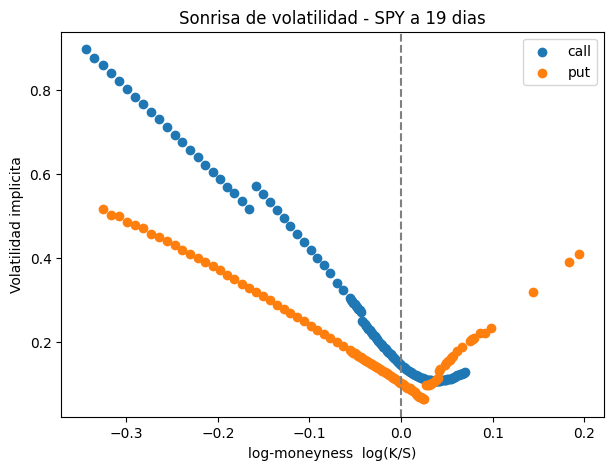

In [9]:
# La sonrisa de volatilidad: VI contra moneyness, para un solo vencimiento de SPY
spy = df[(df['ticker'] == 'SPY')]
venc = sorted(spy['dias_venc'].unique())[2]   # un vencimiento intermedio
corte = spy[spy['dias_venc'] == venc]

plt.figure(figsize=(7, 5))
plt.scatter(corte[corte['tipo'] == 'call']['logm'],
            corte[corte['tipo'] == 'call']['impliedVolatility'], label='call')
plt.scatter(corte[corte['tipo'] == 'put']['logm'],
            corte[corte['tipo'] == 'put']['impliedVolatility'], label='put')
plt.axvline(0, color='gray', linestyle='--')
plt.xlabel('log-moneyness  log(K/S)')
plt.ylabel('Volatilidad implicita')
plt.title('Sonrisa de volatilidad - SPY a ' + str(venc) + ' dias')
plt.legend()
plt.show()

La curvatura se ve a simple vista: la VI baja conforme el strike se acerca al spot, toca un mínimo
ligeramente a la derecha del *at the money* (línea punteada) y vuelve a subir. La rama izquierda (strikes
abajo del spot) está **mucho más alta** que la derecha: ese es el *skew* de renta variable. Un modelo lineal
no puede reproducir esta forma.

Hay un segundo detalle importante: **para un mismo strike, calls y puts no tienen la misma VI**, y la
diferencia cambia según el moneyness. En la rama izquierda las calls (que ahí están dentro del dinero)
cotizan VI mucho más alta que las puts. Eso anticipa que el tipo de opción debe entrar como factor y que su
efecto probablemente **interactúa** con el moneyness.

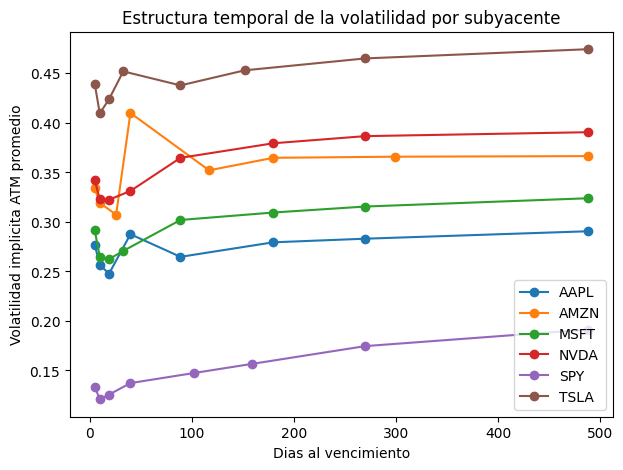

In [10]:
# Estructura temporal: como cambia la VI at-the-money con el plazo
atm = df[np.abs(df['logm']) < 0.02]

plt.figure(figsize=(7, 5))
for tk in sorted(df['ticker'].unique()):
    sub = atm[atm['ticker'] == tk].groupby('dias_venc')['impliedVolatility'].mean()
    plt.plot(sub.index, sub.values, marker='o', label=tk)

plt.xlabel('Dias al vencimiento')
plt.ylabel('Volatilidad implicita ATM promedio')
plt.title('Estructura temporal de la volatilidad por subyacente')
plt.legend()
plt.show()

Dos cosas importantes. Primero, los niveles de VI son claramente distintos entre subyacentes: SPY está
muy por debajo de todos (es un índice diversificado) y TSLA muy por arriba, lo que confirma que `ticker`
debe entrar como factor. Segundo, la relación con el plazo **no es una recta**: en la mayoría de los
subyacentes la VI *at the money* sube conforme el plazo es mayor (estructura en *contango*), pero con saltos
puntuales en los vencimientos cortos —por ejemplo AMZN alrededor de los 40 días—, que suelen asociarse a
eventos concretos como reportes de resultados.

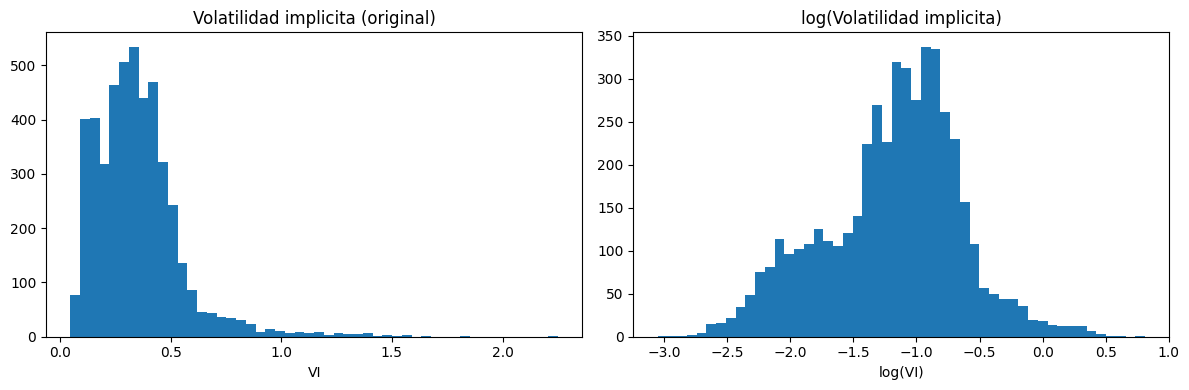

Sesgo de la VI original: 2.052
Sesgo de log(VI):       -0.247


In [11]:
# Distribucion de la variable dependiente, antes y despues del logaritmo
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df['impliedVolatility'], bins=50)
ax[0].set_title('Volatilidad implicita (original)')
ax[0].set_xlabel('VI')

ax[1].hist(df['logIV'], bins=50)
ax[1].set_title('log(Volatilidad implicita)')
ax[1].set_xlabel('log(VI)')

plt.tight_layout()
plt.show()

print('Sesgo de la VI original:', round(df['impliedVolatility'].skew(), 3))
print('Sesgo de log(VI):      ', round(df['logIV'].skew(), 3))

La VI original está fuertemente sesgada a la derecha; al aplicar logaritmo la distribución se vuelve
mucho más simétrica. Esto ya anticipa el resultado del análisis de residuos de la sección 6.

## 5. Pipeline

### 5.1 Diagrama del pipeline

El siguiente diagrama resume todo el flujo del trabajo, desde el dato crudo hasta la comparación de los
doce ajustes. Un punto clave del diseño: **el escalamiento y la generación de potencias viven dentro del
pipeline, después del split**. Si se escalara sobre el dataset completo antes de separar, la media y la
desviación del conjunto de prueba se filtrarían al entrenamiento (*data leakage*) y el R² de prueba estaría
inflado.

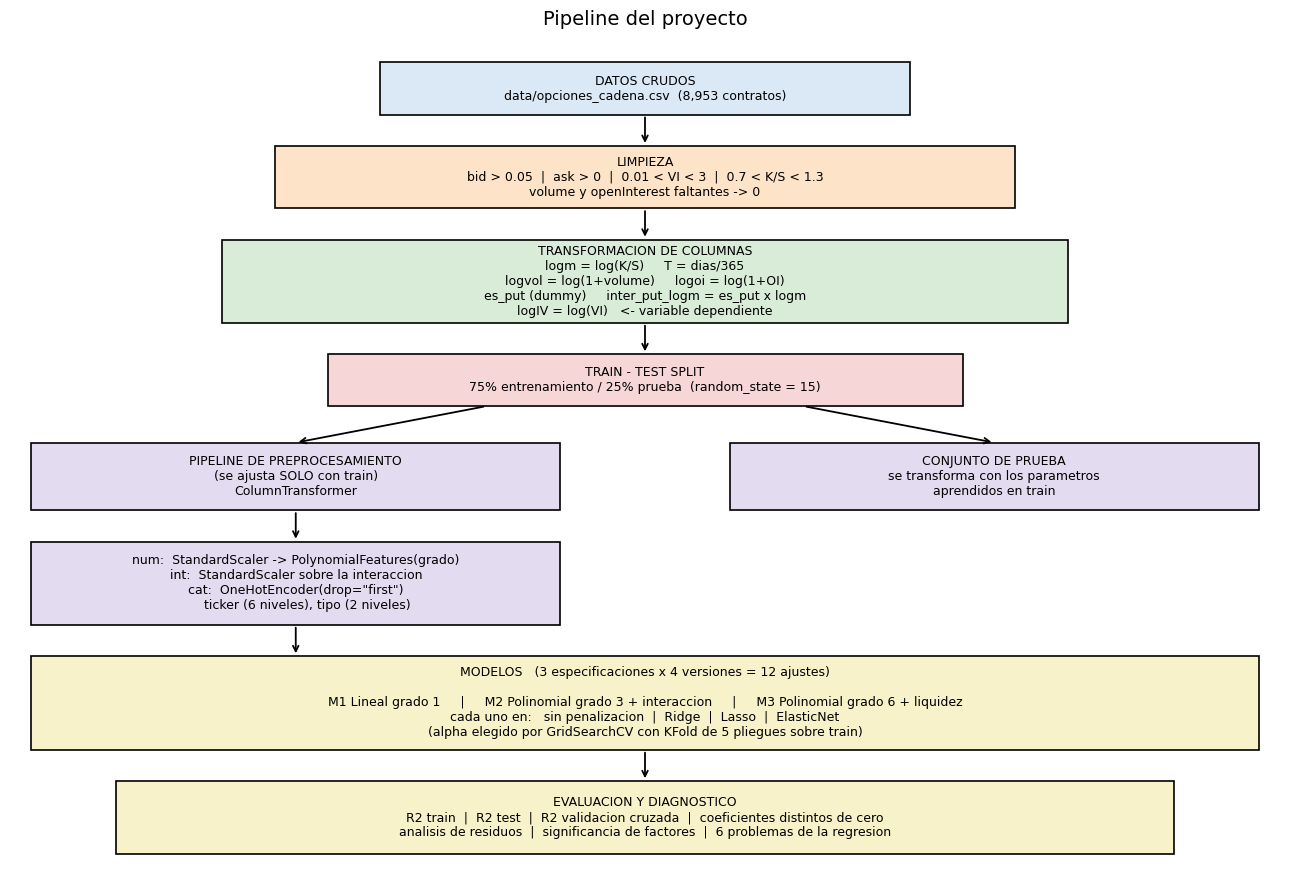

In [12]:
fig, ax = plt.subplots(figsize=(13, 9))

# Funcion chica para dibujar cada caja del diagrama
def caja(x, y, ancho, alto, texto, color):
    ax.add_patch(plt.Rectangle((x, y), ancho, alto, facecolor=color,
                               edgecolor='black', linewidth=1.2))
    ax.text(x + ancho/2, y + alto/2, texto, ha='center', va='center', fontsize=9)

# Funcion chica para dibujar las flechas
def flecha(x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', linewidth=1.3, color='black'))

c_dato = '#dbe9f6'; c_limp = '#fde3c8'; c_trans = '#d8ecd8'
c_split = '#f6d6d6'; c_pipe = '#e3dcf0'; c_eval = '#f7f2c9'

caja(3.5, 15.2, 5, 1.0, 'DATOS CRUDOS\ndata/opciones_cadena.csv  (8,953 contratos)', c_dato)
flecha(6, 15.2, 6, 14.6)

caja(2.5, 13.4, 7, 1.2, 'LIMPIEZA\nbid > 0.05  |  ask > 0  |  0.01 < VI < 3  |  0.7 < K/S < 1.3\n'
                        'volume y openInterest faltantes -> 0', c_limp)
flecha(6, 13.4, 6, 12.8)

caja(2.0, 11.2, 8, 1.6, 'TRANSFORMACION DE COLUMNAS\n'
                        'logm = log(K/S)     T = dias/365\n'
                        'logvol = log(1+volume)     logoi = log(1+OI)\n'
                        'es_put (dummy)     inter_put_logm = es_put x logm\n'
                        'logIV = log(VI)   <- variable dependiente', c_trans)
flecha(6, 11.2, 6, 10.6)

caja(3.0, 9.6, 6, 1.0, 'TRAIN - TEST SPLIT\n75% entrenamiento / 25% prueba  (random_state = 15)', c_split)
flecha(4.5, 9.6, 2.7, 8.9)
flecha(7.5, 9.6, 9.3, 8.9)

caja(0.2, 7.6, 5.0, 1.3, 'PIPELINE DE PREPROCESAMIENTO\n(se ajusta SOLO con train)\n'
                         'ColumnTransformer', c_pipe)
caja(6.8, 7.6, 5.0, 1.3, 'CONJUNTO DE PRUEBA\nse transforma con los parametros\n'
                         'aprendidos en train', c_pipe)
flecha(2.7, 7.6, 2.7, 7.0)

caja(0.2, 5.4, 5.0, 1.6, 'num:  StandardScaler -> PolynomialFeatures(grado)\n'
                         'int:  StandardScaler sobre la interaccion\n'
                         'cat:  OneHotEncoder(drop="first")\n'
                         '      ticker (6 niveles), tipo (2 niveles)', c_pipe)
flecha(2.7, 5.4, 2.7, 4.8)

caja(0.2, 3.0, 11.6, 1.8, 'MODELOS   (3 especificaciones x 4 versiones = 12 ajustes)\n\n'
                          'M1 Lineal grado 1     |     M2 Polinomial grado 3 + interaccion     |     '
                          'M3 Polinomial grado 6 + liquidez\n'
                          'cada uno en:   sin penalizacion  |  Ridge  |  Lasso  |  ElasticNet\n'
                          '(alpha elegido por GridSearchCV con KFold de 5 pliegues sobre train)', c_eval)
flecha(6, 3.0, 6, 2.4)

caja(1.0, 1.0, 10.0, 1.4, 'EVALUACION Y DIAGNOSTICO\n'
                          'R2 train  |  R2 test  |  R2 validacion cruzada  |  coeficientes distintos de cero\n'
                          'analisis de residuos  |  significancia de factores  |  6 problemas de la regresion', c_eval)

ax.set_xlim(0, 12); ax.set_ylim(0.5, 16.6)
ax.axis('off')
ax.set_title('Pipeline del proyecto', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

### 5.2 Separación train–test

Se usa una separación 75/25 con semilla fija. El corte es aleatorio y no por vencimiento, porque el
objetivo es **interpolar la superficie**, no extrapolar hacia plazos que el modelo nunca vio.

In [13]:
# Variables que van a entrar a los modelos
X = df[['logm', 'T', 'logvol', 'logoi', 'inter_put_logm', 'ticker', 'tipo']]
y = df['logIV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEMILLA)

print('Entrenamiento:', X_train.shape[0], 'contratos')
print('Prueba:       ', X_test.shape[0], 'contratos')

Entrenamiento: 3532 contratos
Prueba:        1178 contratos


### 5.3 Funciones auxiliares

Para no repetir doce bloques de código casi idénticos, se definen dos funciones cortas: una que arma el
preprocesador y otra que ajusta las cuatro versiones de un mismo modelo.

In [14]:
def construir_preprocesador(columnas_num, grado, con_interaccion):
    """Arma el ColumnTransformer del modelo.

    columnas_num    : lista de variables numericas que se elevan a potencias
    grado           : grado del polinomio
    con_interaccion : True si se incluye el termino es_put x logm
    """
    # A las numericas primero se les quita la escala y luego se generan las potencias.
    # Ese orden es importante: si se elevan a potencias sin escalar, los numeros explotan.
    bloque_num = Pipeline([
        ('escala', StandardScaler()),
        ('potencias', PolynomialFeatures(degree=grado, include_bias=False))
    ])

    pasos = [('num', bloque_num, columnas_num)]

    if con_interaccion:
        pasos.append(('inter', StandardScaler(), ['inter_put_logm']))

    # Las cualitativas se vuelven dummies. drop='first' evita la dummy variable trap.
    pasos.append(('cat', OneHotEncoder(drop='first'), ['ticker', 'tipo']))

    return ColumnTransformer(transformers=pasos, remainder='drop')

In [15]:
# Rejillas de alpha para buscar la penalizacion optima
ALPHAS_RIDGE = [0.001, 0.01, 0.1, 1, 10, 100, 500]
ALPHAS_LASSO = [0.0001, 0.001, 0.01, 0.1]
L1_RATIOS    = [0.5, 0.8]

# Esquema de validacion cruzada que se usa en todo el trabajo
kfold = KFold(n_splits=5, shuffle=True, random_state=SEMILLA)


def ajustar_cuatro_versiones(preprocesador, columnas, nombre_modelo):
    """Ajusta el mismo modelo en sus 4 versiones y regresa los resultados.

    Devuelve (tabla de resultados, diccionario con los pipelines ya ajustados).
    """
    Xtr = X_train[columnas]
    Xte = X_test[columnas]

    # Cada version se define como: nombre, estimador, rejilla de hiperparametros
    versiones = [
        ('Sin penalizacion', LinearRegression(), {}),
        ('Ridge',      Ridge(),      {'modelo__alpha': ALPHAS_RIDGE}),
        ('Lasso',      Lasso(max_iter=20000, tol=1e-3), {'modelo__alpha': ALPHAS_LASSO}),
        ('ElasticNet', ElasticNet(max_iter=20000, tol=1e-3),
                       {'modelo__alpha': ALPHAS_LASSO, 'modelo__l1_ratio': L1_RATIOS}),
    ]

    filas = []
    ajustados = {}

    for nombre, estimador, rejilla in versiones:
        pipe = Pipeline([('preprocesador', preprocesador), ('modelo', estimador)])

        if rejilla:
            # Buscamos el alpha que da mejor R2 promedio en validacion cruzada
            busqueda = GridSearchCV(pipe, rejilla, cv=kfold, scoring='r2', n_jobs=-1)
            busqueda.fit(Xtr, y_train)
            mejor = busqueda.best_estimator_
            alpha = busqueda.best_params_['modelo__alpha']
            r2_cv = busqueda.best_score_
        else:
            mejor = pipe
            mejor.fit(Xtr, y_train)
            alpha = np.nan
            r2_cv = cross_val_score(pipe, Xtr, y_train, cv=kfold, scoring='r2').mean()

        coeficientes = mejor['modelo'].coef_
        filas.append({
            'Modelo': nombre_modelo,
            'Version': nombre,
            'alpha': alpha,
            'R2 train': mejor.score(Xtr, y_train),
            'R2 test': mejor.score(Xte, y_test),
            'R2 CV': r2_cv,
            'No. coef': len(coeficientes),
            'Coef != 0': int(np.sum(np.abs(coeficientes) > 1e-8))
        })
        ajustados[nombre] = mejor

    return pd.DataFrame(filas), ajustados

In [16]:
def graficar_residuos(modelo_ajustado, columnas, titulo):
    """Grafica el diagnostico de residuos de un modelo ya ajustado."""
    pred = modelo_ajustado.predict(X_train[columnas])
    residuos = y_train - pred

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))

    # 1) Residuos contra valores predichos: busca curvatura y embudo
    ax[0].scatter(pred, residuos, s=6, alpha=0.4)
    ax[0].axhline(0, color='red')
    ax[0].set_xlabel('Valores predichos')
    ax[0].set_ylabel('Residuos')
    ax[0].set_title('Residuos vs predichos')

    # 2) Residuos contra log-moneyness: busca la sonrisa sin capturar
    ax[1].scatter(X_train['logm'], residuos, s=6, alpha=0.4)
    ax[1].axhline(0, color='red')
    ax[1].set_xlabel('log-moneyness')
    ax[1].set_ylabel('Residuos')
    ax[1].set_title('Residuos vs log-moneyness')

    # 3) Histograma de residuos: busca simetria
    ax[2].hist(residuos, bins=50)
    ax[2].set_xlabel('Residuos')
    ax[2].set_title('Distribucion de residuos')

    fig.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.show()

    print('Media de los residuos:', round(residuos.mean(), 5))
    print('Desviacion estandar:  ', round(residuos.std(), 5))

## 6. Justificación de la transformación de la variable dependiente

Antes de definir los tres modelos hay que decidir si se modela la VI directamente o su logaritmo. Esa
decisión **no se asume: se toma viendo los residuos**. Se ajusta un modelo lineal sencillo con la VI en su
escala original y se revisa qué forma tienen sus residuos.

R2 con la VI sin transformar: 0.4527


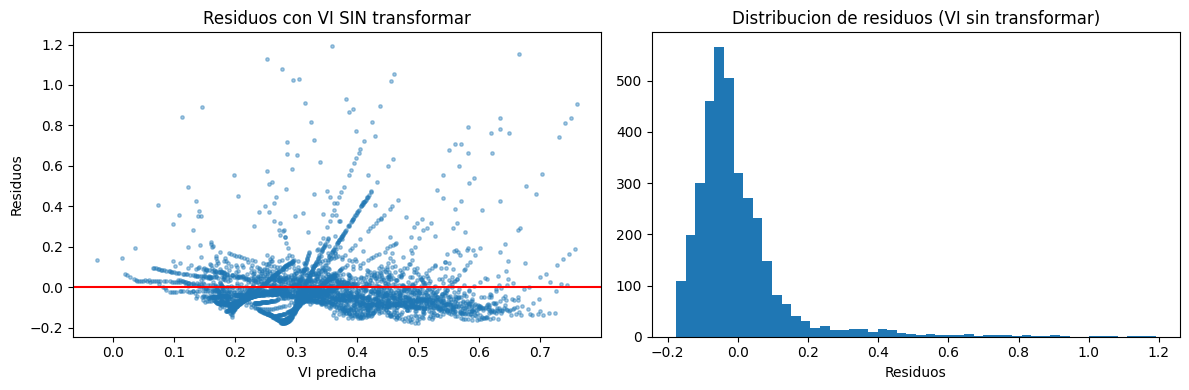

In [17]:
# Modelo preliminar: VI SIN transformar, especificacion lineal simple
pre_prelim = construir_preprocesador(['logm', 'T'], grado=1, con_interaccion=False)
pipe_prelim = Pipeline([('preprocesador', pre_prelim), ('modelo', LinearRegression())])

cols_prelim = ['logm', 'T', 'ticker', 'tipo']
y_train_cruda = df.loc[X_train.index, 'impliedVolatility']

pipe_prelim.fit(X_train[cols_prelim], y_train_cruda)
pred_prelim = pipe_prelim.predict(X_train[cols_prelim])
res_prelim = y_train_cruda - pred_prelim

print('R2 con la VI sin transformar:', round(pipe_prelim.score(X_train[cols_prelim], y_train_cruda), 4))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(pred_prelim, res_prelim, s=6, alpha=0.4)
ax[0].axhline(0, color='red')
ax[0].set_xlabel('VI predicha'); ax[0].set_ylabel('Residuos')
ax[0].set_title('Residuos con VI SIN transformar')

ax[1].hist(res_prelim, bins=50)
ax[1].set_xlabel('Residuos')
ax[1].set_title('Distribucion de residuos (VI sin transformar)')
plt.tight_layout()
plt.show()

In [18]:
# Prueba formal de heterocedasticidad sobre el modelo preliminar
X_prelim_sm = sm.add_constant(pre_prelim.fit_transform(X_train[cols_prelim]))
ols_prelim = sm.OLS(y_train_cruda.values, X_prelim_sm).fit()

bp_prelim = het_breuschpagan(ols_prelim.resid, ols_prelim.model.exog)
print('Breusch-Pagan con VI sin transformar -> LM:', round(bp_prelim[0], 2),
      '| p-value:', bp_prelim[1])

Breusch-Pagan con VI sin transformar -> LM: 101.09 | p-value: 2.5544195064726012e-18


**Lectura del diagnóstico.** Los residuos con la VI sin transformar muestran dos problemas:

1. **Una distribución muy sesgada a la derecha**, con una cola larga de contratos cuya VI el modelo
   subestima muchísimo (residuos de hasta +1.2, cuando la mayoría está entre −0.2 y +0.2).
2. **Una dispersión que crece con el nivel**: los contratos con VI predicha alta tienen residuos más
   dispersos que los de VI predicha baja. Breusch–Pagan confirma la heterocedasticidad.

Además, el modelo puede predecir valores de VI **negativos**, lo cual no tiene sentido financiero.

Para decidir la transformación, se compara numéricamente qué pasa con los residuos si en lugar de la VI se
modela su logaritmo, con **exactamente las mismas variables explicativas**.

In [19]:
# Mismo modelo, pero con log(VI) como variable dependiente
ols_prelim_log = sm.OLS(y_train.values, X_prelim_sm).fit()

# Dividimos las predicciones en 5 grupos (quintiles) y vemos la dispersion de los residuos en cada uno.
# Si la dispersion crece de un grupo a otro, hay un embudo.
grupos_cruda = pd.qcut(ols_prelim.fittedvalues, 5, labels=False)
grupos_log = pd.qcut(ols_prelim_log.fittedvalues, 5, labels=False)

disp_cruda = pd.Series(ols_prelim.resid).groupby(grupos_cruda).std()
disp_log = pd.Series(ols_prelim_log.resid).groupby(grupos_log).std()

comparacion = pd.DataFrame({
    'Desv. residuos - VI cruda': disp_cruda.values,
    'Desv. residuos - log(VI)': disp_log.values
}, index=['Q1 (pred. baja)', 'Q2', 'Q3', 'Q4', 'Q5 (pred. alta)'])
print(comparacion.round(4))
print()
print('Sesgo de los residuos       -> VI cruda:', round(pd.Series(ols_prelim.resid).skew(), 3),
      '| log(VI):', round(pd.Series(ols_prelim_log.resid).skew(), 3))
print('Predicciones negativas      -> VI cruda:', int((ols_prelim.fittedvalues < 0).sum()),
      '| log(VI): 0 (exp() siempre es positiva)')

bp_prelim_log = het_breuschpagan(ols_prelim_log.resid, ols_prelim_log.model.exog)
print('Breusch-Pagan               -> VI cruda: p =', '%.2e' % bp_prelim[1],
      '| log(VI): p =', '%.2e' % bp_prelim_log[1])

                 Desv. residuos - VI cruda  Desv. residuos - log(VI)
Q1 (pred. baja)                     0.0964                    0.3676
Q2                                  0.1346                    0.3864
Q3                                  0.1230                    0.3184
Q4                                  0.1821                    0.3136
Q5 (pred. alta)                     0.1659                    0.2202

Sesgo de los residuos       -> VI cruda: 3.28 | log(VI): 0.899
Predicciones negativas      -> VI cruda: 1 | log(VI): 0 (exp() siempre es positiva)
Breusch-Pagan               -> VI cruda: p = 2.55e-18 | log(VI): p = 2.08e-57


**Decisión.** Se adopta $\log(VI)$ como variable dependiente, por estas razones:

1. **El sesgo de los residuos baja de forma muy marcada**, lo que acerca el modelo al supuesto de errores
   aproximadamente simétricos.
2. **La dispersión deja de crecer con el nivel de la VI.** Con la VI cruda, la desviación de los residuos
   aumenta al pasar de los quintiles de predicción baja a los de predicción alta (embudo). Con el logaritmo
   ese patrón creciente desaparece: la dispersión incluso es menor en el quintil más alto.
3. **Todas las predicciones son positivas** al deshacer la transformación con `exp()`.
4. **Tiene sentido financiero**: la VI es multiplicativa. Que una VI de 20% suba 10 puntos no es lo mismo
   que una de 80% suba 10 puntos; en logaritmos, los coeficientes se leen como cambios porcentuales.

**Lo que el logaritmo NO resuelve:** Breusch–Pagan sigue detectando heterocedasticidad, así que la varianza
de los errores sigue sin ser constante. La transformación cambió la *forma* del problema (ya no es un embudo
proporcional al nivel) pero no lo eliminó. Buena parte de la varianza sobrante viene de la curvatura que el
modelo lineal todavía no captura y de la liquidez de los contratos; ambas cosas se atacan en los modelos
siguientes, y la heterocedasticidad restante se trata en la sección 12.6 con errores estándar robustos.

**Todos los modelos de aquí en adelante usan `logIV` como variable dependiente.**

## 7. Modelo 1 — Lineal

### 7.1 Especificación

$$\log(VI) = \beta_0 + \beta_1 \, \text{logm} + \beta_2 \, T + \sum_{k} \gamma_k \, D_{ticker,k} + \delta \, D_{put} + \varepsilon$$

Es el modelo base: todo entra de forma aditiva y lineal. Sirve como punto de comparación para medir cuánto
aportan realmente las transformaciones polinomiales.

In [20]:
cols_m1 = ['logm', 'T', 'ticker', 'tipo']
pre_m1 = construir_preprocesador(['logm', 'T'], grado=1, con_interaccion=False)

tabla_m1, ajustados_m1 = ajustar_cuatro_versiones(pre_m1, cols_m1, 'M1 Lineal')
tabla_m1.round(4)

,Modelo,Version,alpha,R2 train,R2 test,R2 CV,No. coef,Coef != 0
0,M1 Lineal,Sin penalizacion,NaN,0.5835,0.5396,0.5811,8,8
1,M1 Lineal,Ridge,1.0000,0.5835,0.5397,0.5811,8,8
2,M1 Lineal,Lasso,0.0001,0.5835,0.5397,0.5811,8,8
3,M1 Lineal,ElasticNet,0.0001,0.5835,0.5397,0.5811,8,8


### 7.2 Análisis de residuos del Modelo 1

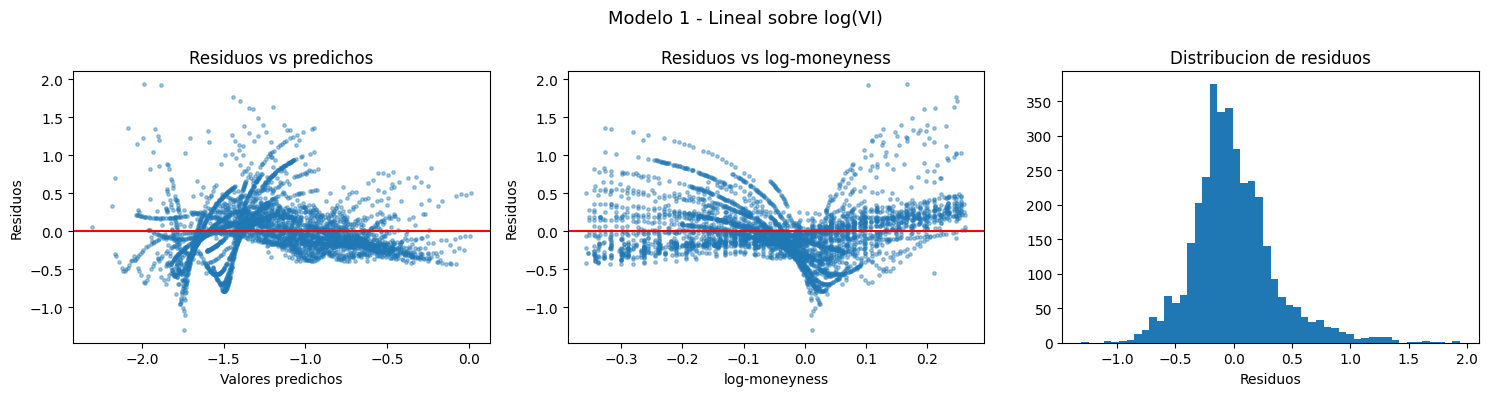

Media de los residuos: -0.0
Desviacion estandar:   0.35313


In [21]:
graficar_residuos(ajustados_m1['Sin penalizacion'], cols_m1,
                  'Modelo 1 - Lineal sobre log(VI)')

**Lectura del diagnóstico.** La distribución de los residuos ya es mucho más simétrica que con la VI
cruda. Pero la gráfica de residuos contra log-moneyness muestra con toda claridad **el problema principal
de este modelo**: tiene forma de **U**. El modelo subestima la VI en los extremos (strikes muy arriba y muy
abajo del spot) y la sobreestima cerca del dinero, con una caída muy marcada justo a la derecha de cero.
La gráfica de residuos contra predichos tampoco es una nube sin forma: tiene arcos y curvas, otra señal de
que la especificación lineal está incompleta.

Esa U es exactamente la sonrisa de volatilidad que el modelo lineal no puede reproducir. No es ruido: es
estructura sistemática que quedó sin explicar.

**Transformación que se adopta para el siguiente modelo:** agregar **términos polinomiales en `logm` y
`T`**, que es lo que permite curvatura, y agregar la **interacción `put × logm`**, porque la rama
izquierda y la derecha de la sonrisa no tienen la misma pendiente.

## 8. Modelo 2 — Polinomial grado 3 con interacción

### 8.1 Especificación

$$\log(VI) = \beta_0 + \sum_{a+b \leq 3} \beta_{ab} \, \text{logm}^a \, T^b
+ \theta \, (D_{put} \cdot \text{logm}) + \sum_{k} \gamma_k \, D_{ticker,k} + \delta \, D_{put} + \varepsilon$$

`PolynomialFeatures(degree=3)` sobre `logm` y `T` genera nueve términos: las potencias de cada variable
hasta grado 3 y todos los productos cruzados (`logm·T`, `logm²·T`, `logm·T²`, etc.). Esos productos
cruzados **son interacciones entre variables cuantitativas**, y tienen una lectura financiera directa: el
skew no es igual en todos los plazos.

Además se agrega explícitamente la interacción cualitativa × cuantitativa `es_put × logm`, que permite que
calls y puts tengan pendientes distintas respecto al moneyness.

El grado 3 se escogió porque es el mínimo que permite representar una curva asimétrica: el grado 2 obliga a
una parábola perfectamente simétrica, y la sonrisa de renta variable no lo es.

In [22]:
cols_m2 = ['logm', 'T', 'inter_put_logm', 'ticker', 'tipo']
pre_m2 = construir_preprocesador(['logm', 'T'], grado=3, con_interaccion=True)

tabla_m2, ajustados_m2 = ajustar_cuatro_versiones(pre_m2, cols_m2, 'M2 Polinomial g3')
tabla_m2.round(4)

,Modelo,Version,alpha,R2 train,R2 test,R2 CV,No. coef,Coef != 0
0,M2 Polinomial g3,Sin penalizacion,NaN,0.7386,0.7217,0.735,16,16
1,M2 Polinomial g3,Ridge,1.0000,0.7386,0.7217,0.735,16,16
2,M2 Polinomial g3,Lasso,0.0001,0.7386,0.7217,0.735,16,16
3,M2 Polinomial g3,ElasticNet,0.0001,0.7386,0.7217,0.735,16,16


### 8.2 Análisis de residuos del Modelo 2

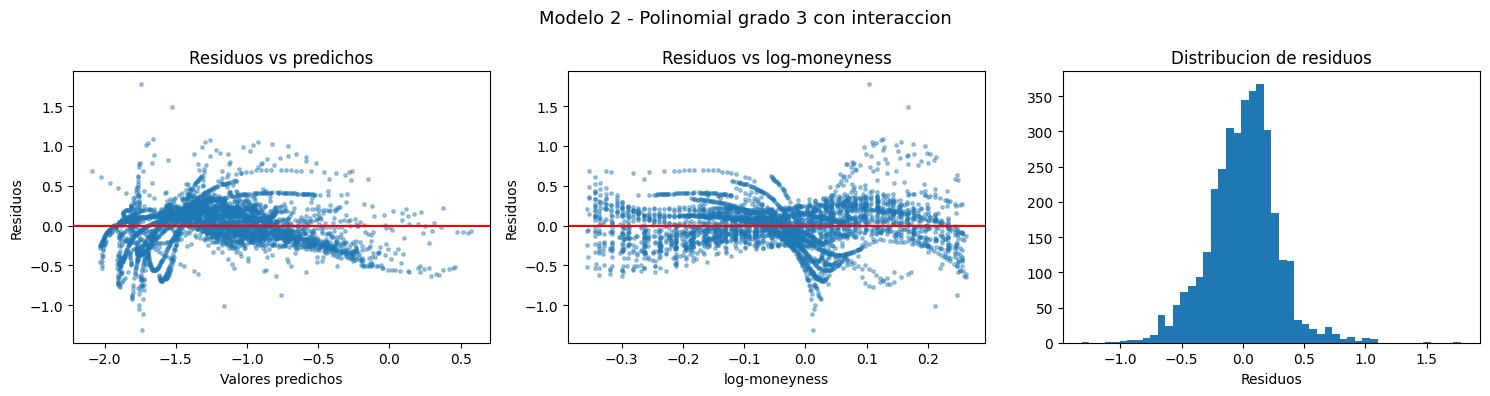

Media de los residuos: 0.0
Desviacion estandar:   0.27976


In [23]:
graficar_residuos(ajustados_m2['Sin penalizacion'], cols_m2,
                  'Modelo 2 - Polinomial grado 3 con interaccion')

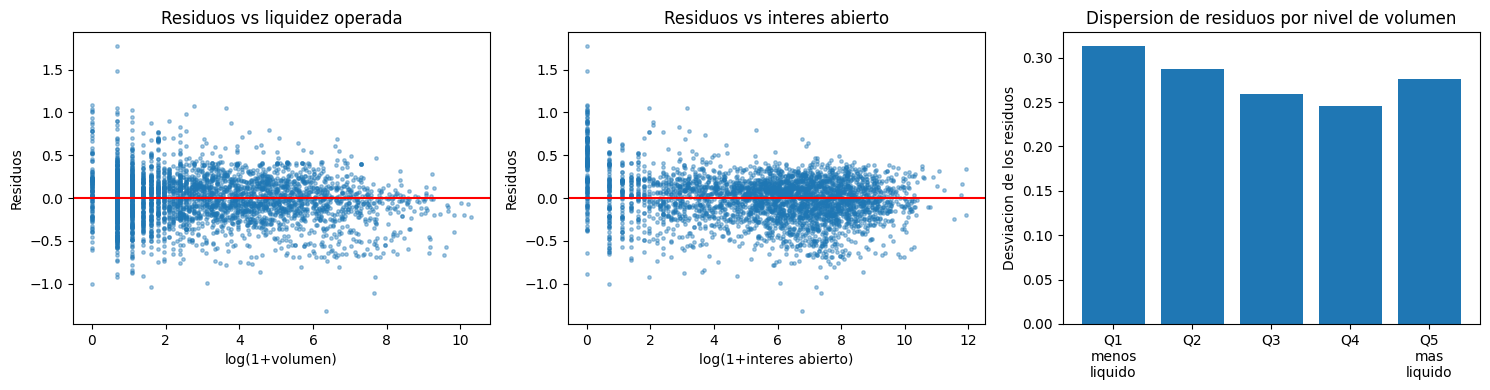

Correlacion residuos vs logvol: -0.1521
Correlacion residuos vs logoi:  -0.2573

Desviacion de los residuos por quintil de volumen:
logvol
Q1\nmenos\nliquido    0.3129
Q2                    0.2877
Q3                    0.2588
Q4                    0.2451
Q5\nmas\nliquido      0.2761


In [24]:
# Revisamos si queda estructura asociada a variables que el modelo NO incluye
pred_m2 = ajustados_m2['Sin penalizacion'].predict(X_train[cols_m2])
res_m2 = y_train - pred_m2

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].scatter(X_train['logvol'], res_m2, s=6, alpha=0.4)
ax[0].axhline(0, color='red')
ax[0].set_xlabel('log(1+volumen)'); ax[0].set_ylabel('Residuos')
ax[0].set_title('Residuos vs liquidez operada')

ax[1].scatter(X_train['logoi'], res_m2, s=6, alpha=0.4)
ax[1].axhline(0, color='red')
ax[1].set_xlabel('log(1+interes abierto)'); ax[1].set_ylabel('Residuos')
ax[1].set_title('Residuos vs interes abierto')

# Dispersion de los residuos segun el nivel de liquidez (5 grupos de volumen)
grupos_liq = pd.qcut(X_train['logvol'].rank(method='first'), 5,
                     labels=['Q1\nmenos\nliquido', 'Q2', 'Q3', 'Q4', 'Q5\nmas\nliquido'])
disp_liq = res_m2.groupby(grupos_liq).std()
ax[2].bar(disp_liq.index.astype(str), disp_liq.values)
ax[2].set_ylabel('Desviacion de los residuos')
ax[2].set_title('Dispersion de residuos por nivel de volumen')

plt.tight_layout()
plt.show()

# Correlacion de los residuos con las variables que no estan en el modelo
print('Correlacion residuos vs logvol:', round(np.corrcoef(X_train['logvol'], res_m2)[0, 1], 4))
print('Correlacion residuos vs logoi: ', round(np.corrcoef(X_train['logoi'], res_m2)[0, 1], 4))
print()
print('Desviacion de los residuos por quintil de volumen:')
print(disp_liq.round(4).to_string())

**Lectura del diagnóstico.** La U grande desapareció: los residuos contra log-moneyness ya están
centrados en cero en casi todo el rango, así que el polinomio de grado 3 sí capturó la forma general de la
sonrisa. Queda una caída localizada justo a la derecha del *at the money* (log-moneyness entre 0 y 0.05):
el fondo de la sonrisa real es más "puntiagudo" de lo que un polinomio de grado 3 puede reproducir.

Además, los residuos **todavía están relacionados con las variables de liquidez**, que este modelo no
incluye:

- La correlación de los residuos con `logvol` y con `logoi` es **negativa**: los contratos poco líquidos
  tienden a tener residuos positivos, es decir, su VI real está **por arriba** de lo que el modelo predice.
- La dispersión de los residuos es **mayor en los contratos menos líquidos** y tiende a bajar conforme
  aumenta el volumen. Esa es una fuente concreta de la heterocedasticidad que se detectó.

Las dos cosas tienen sentido económico: los contratos poco operados tienen spreads anchos, y la VI que se
despeja de un precio con spread ancho es más ruidosa y suele salir inflada.

**Transformación que se adopta para el siguiente modelo:** incorporar `logvol` y `logoi` como variables
explicativas y **subir el grado del polinomio a 6**, dejando que el modelo use también todos los productos
cruzados entre moneyness, plazo y liquidez. El resultado es un modelo con más de 200 columnas — justo el
escenario donde la regularización debería empezar a importar.

## 9. Modelo 3 — Polinomial grado 6 con liquidez

### 9.1 Especificación

$$\log(VI) = \beta_0 + \sum_{a+b+c+d \leq 6} \beta_{abcd} \, \text{logm}^a \, T^b \, \text{logvol}^c \, \text{logoi}^d
+ \theta \, (D_{put} \cdot \text{logm}) + \sum_{k} \gamma_k \, D_{ticker,k} + \delta \, D_{put} + \varepsilon$$

Cuatro variables numéricas elevadas hasta grado 6 generan **209 términos polinomiales**, que junto con la
interacción y las dummies dan 216 columnas en la matriz de diseño. Este modelo se construye a propósito
como un modelo **sobre-parametrizado**: es el escenario donde MCO empieza a sobreajustar y donde Ridge,
Lasso y ElasticNet tienen algo real que aportar.

Aunque las variables se estandarizan antes de generar las potencias, las potencias altas de una misma
variable (por ejemplo `T⁴`, `T⁵`, `T⁶`) siguen muy correlacionadas entre sí, así que este modelo tiene un
problema de **colinealidad** por construcción. Ese es precisamente el caso para el que Ridge fue diseñado.

In [25]:
cols_m3 = ['logm', 'T', 'logvol', 'logoi', 'inter_put_logm', 'ticker', 'tipo']
pre_m3 = construir_preprocesador(['logm', 'T', 'logvol', 'logoi'], grado=6, con_interaccion=True)

# Cuantas columnas genera este preprocesador
n_cols_m3 = pre_m3.fit_transform(X_train[cols_m3]).shape[1]
print('Columnas en la matriz de disenio del Modelo 3:', n_cols_m3)

tabla_m3, ajustados_m3 = ajustar_cuatro_versiones(pre_m3, cols_m3, 'M3 Polinomial g6')
tabla_m3.round(4)

Columnas en la matriz de disenio del Modelo 3: 216


,Modelo,Version,alpha,R2 train,R2 test,R2 CV,No. coef,Coef != 0
0,M3 Polinomial g6,Sin penalizacion,NaN,0.8752,0.8471,0.6823,216,216
1,M3 Polinomial g6,Ridge,100.000,0.8491,0.8347,0.8100,216,216
2,M3 Polinomial g6,Lasso,0.001,0.8592,0.8431,0.8385,216,136
3,M3 Polinomial g6,ElasticNet,0.001,0.8612,0.8442,0.8377,216,145


### 9.2 Análisis de residuos del Modelo 3

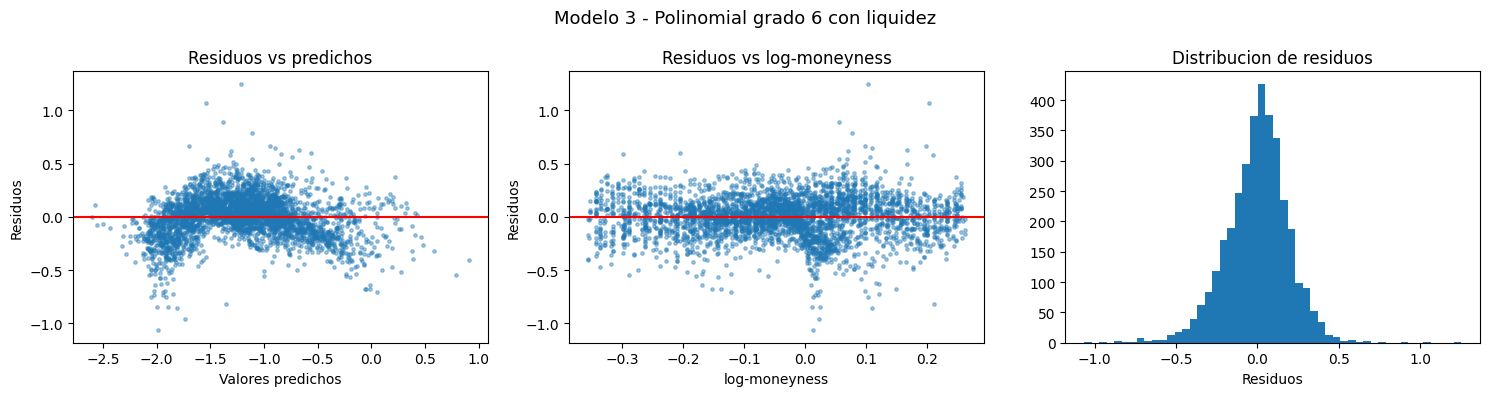

Media de los residuos: 0.0
Desviacion estandar:   0.19326


In [26]:
graficar_residuos(ajustados_m3['Sin penalizacion'], cols_m3,
                  'Modelo 3 - Polinomial grado 6 con liquidez')

In [27]:
# Cuantos coeficientes deja Lasso exactamente en cero
coef_ols_m3 = ajustados_m3['Sin penalizacion']['modelo'].coef_
coef_ridge_m3 = ajustados_m3['Ridge']['modelo'].coef_
coef_lasso_m3 = ajustados_m3['Lasso']['modelo'].coef_
coef_enet_m3 = ajustados_m3['ElasticNet']['modelo'].coef_

print('Total de coeficientes:', len(coef_ols_m3))
print()
print('Coeficientes distintos de cero:')
print('  Sin penalizacion:', int(np.sum(np.abs(coef_ols_m3) > 1e-8)))
print('  Ridge:           ', int(np.sum(np.abs(coef_ridge_m3) > 1e-8)))
print('  Lasso:           ', int(np.sum(np.abs(coef_lasso_m3) > 1e-8)))
print('  ElasticNet:      ', int(np.sum(np.abs(coef_enet_m3) > 1e-8)))
print()
print('Magnitud maxima del coeficiente (que tanto se encogen):')
print('  Sin penalizacion:', round(np.max(np.abs(coef_ols_m3)), 3))
print('  Ridge:           ', round(np.max(np.abs(coef_ridge_m3)), 3))
print('  Lasso:           ', round(np.max(np.abs(coef_lasso_m3)), 3))
print('  ElasticNet:      ', round(np.max(np.abs(coef_enet_m3)), 3))

Total de coeficientes: 216

Coeficientes distintos de cero:
  Sin penalizacion: 216
  Ridge:            216
  Lasso:            136
  ElasticNet:       145

Magnitud maxima del coeficiente (que tanto se encogen):
  Sin penalizacion: 1.098
  Ridge:            0.437
  Lasso:            0.502
  ElasticNet:       0.497


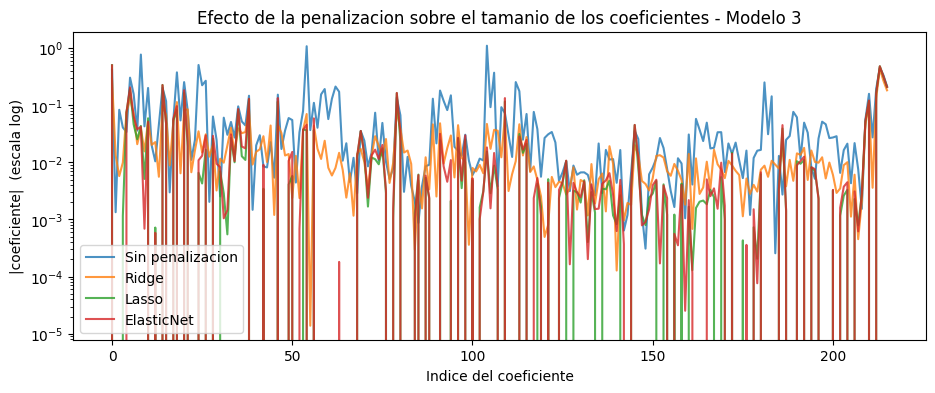

In [28]:
# Comparacion visual del tamanio de los coeficientes
plt.figure(figsize=(11, 4))
plt.plot(np.abs(coef_ols_m3), label='Sin penalizacion', alpha=0.8)
plt.plot(np.abs(coef_ridge_m3), label='Ridge', alpha=0.8)
plt.plot(np.abs(coef_lasso_m3), label='Lasso', alpha=0.8)
plt.plot(np.abs(coef_enet_m3), label='ElasticNet', alpha=0.8)
plt.yscale('log')
plt.xlabel('Indice del coeficiente')
plt.ylabel('|coeficiente|  (escala log)')
plt.title('Efecto de la penalizacion sobre el tamanio de los coeficientes - Modelo 3')
plt.legend()
plt.show()

### 9.3 ¿Qué tan estable es cada versión? R² por pliegue de validación cruzada

La tabla del Modelo 3 muestra algo llamativo: la versión sin penalización tiene el R² de prueba más alto,
pero su R² de validación cruzada es **mucho más bajo** que el de las versiones regularizadas. Para entender
por qué, se revisa el R² de cada uno de los 5 pliegues por separado.

In [29]:
# R2 de cada pliegue para cada version del Modelo 3
r2_pliegues = pd.DataFrame()

for nombre in ['Sin penalizacion', 'Ridge', 'Lasso', 'ElasticNet']:
    r2_pliegues[nombre] = cross_val_score(ajustados_m3[nombre], X_train[cols_m3], y_train,
                                          cv=kfold, scoring='r2')

r2_pliegues.index = ['Pliegue 1', 'Pliegue 2', 'Pliegue 3', 'Pliegue 4', 'Pliegue 5']
print(r2_pliegues.round(4))
print()
print('Promedio:')
print(r2_pliegues.mean().round(4).to_string())
print()
print('Desviacion estandar entre pliegues:')
print(r2_pliegues.std().round(4).to_string())
print()
print('Peor pliegue:')
print(r2_pliegues.min().round(4).to_string())

           Sin penalizacion   Ridge   Lasso  ElasticNet
Pliegue 1            0.8037  0.8206  0.8422      0.8423
Pliegue 2            0.8637  0.8412  0.8617      0.8633
Pliegue 3            0.8330  0.8157  0.8324      0.8337
Pliegue 4            0.6936  0.7672  0.8119      0.8101
Pliegue 5            0.2176  0.8052  0.8443      0.8393

Promedio:
Sin penalizacion    0.6823
Ridge               0.8100
Lasso               0.8385
ElasticNet          0.8377

Desviacion estandar entre pliegues:
Sin penalizacion    0.2676
Ridge               0.0273
Lasso               0.0182
ElasticNet          0.0191

Peor pliegue:
Sin penalizacion    0.2176
Ridge               0.7672
Lasso               0.8119
ElasticNet          0.8101


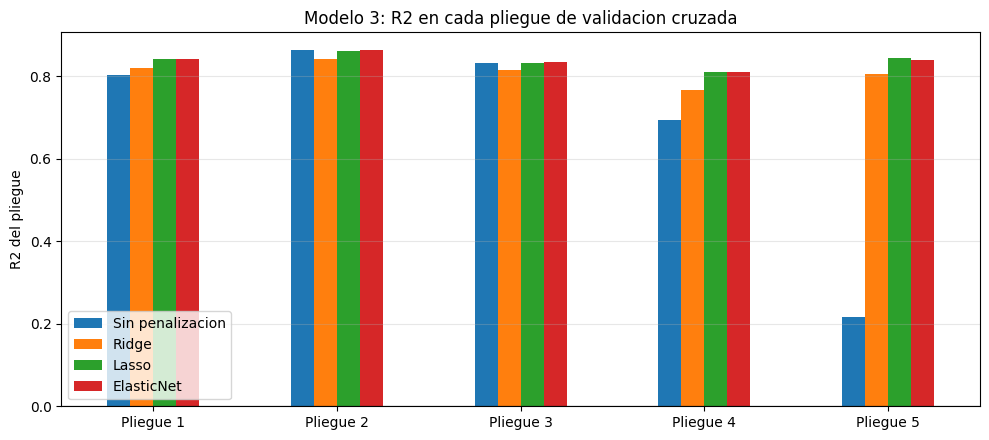

In [30]:
r2_pliegues.plot(kind='bar', figsize=(10, 4.5))
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('R2 del pliegue')
plt.title('Modelo 3: R2 en cada pliegue de validacion cruzada')
plt.xticks(rotation=0)
plt.legend(loc='lower left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Lectura.** Este es el resultado más importante del Modelo 3. La versión sin penalización funciona bien
en algunos pliegues, pero **en uno de ellos su R² se desploma**. Con 216 columnas muy correlacionadas, MCO
produce coeficientes grandes que se cancelan entre sí; mientras los datos nuevos se parecen a los de
entrenamiento todo va bien, pero cuando aparecen combinaciones de valores un poco distintas, las potencias
altas amplifican el error y la predicción se dispara.

Las versiones regularizadas no tienen ese problema: su R² es prácticamente el mismo en los cinco pliegues.
El R² de prueba alto de MCO es, por lo tanto, **un resultado afortunado de una sola partición**, no una
propiedad confiable del modelo. Por eso, para elegir entre versiones, este trabajo usa el **R² de
validación cruzada** y no el R² de un único conjunto de prueba.

## 10. Comparación de los doce ajustes

### 10.1 Tabla resumen

In [31]:
resultados = pd.concat([tabla_m1, tabla_m2, tabla_m3], ignore_index=True)

# Brecha entre entrenamiento y prueba: mide sobreajuste
resultados['Brecha'] = resultados['R2 train'] - resultados['R2 test']

resultados.round(4)

,Modelo,Version,alpha,R2 train,R2 test,R2 CV,No. coef,Coef != 0,Brecha
0,M1 Lineal,Sin penalizacion,NaN,0.5835,0.5396,0.5811,8,8,0.0439
1,M1 Lineal,Ridge,1.0000,0.5835,0.5397,0.5811,8,8,0.0438
2,M1 Lineal,Lasso,0.0001,0.5835,0.5397,0.5811,8,8,0.0438
3,M1 Lineal,ElasticNet,0.0001,0.5835,0.5397,0.5811,8,8,0.0438
4,M2 Polinomial g3,Sin penalizacion,NaN,0.7386,0.7217,0.7350,16,16,0.0169
5,M2 Polinomial g3,Ridge,1.0000,0.7386,0.7217,0.7350,16,16,0.0169
6,M2 Polinomial g3,Lasso,0.0001,0.7386,0.7217,0.7350,16,16,0.0169
7,M2 Polinomial g3,ElasticNet,0.0001,0.7386,0.7217,0.7350,16,16,0.0169
8,M3 Polinomial g6,Sin penalizacion,NaN,0.8752,0.8471,0.6823,216,216,0.0281
9,M3 Polinomial g6,Ridge,100.0000,0.8491,0.8347,0.8100,216,216,0.0144


In [32]:
# Guardamos la tabla para poder citarla en la presentacion
resultados.round(4).to_csv('resultados_modelos.csv', index=False)

# Tabla en formato ancho: mas facil de leer
tabla_ancha = resultados.pivot(index='Version', columns='Modelo', values='R2 test')
tabla_ancha = tabla_ancha[['M1 Lineal', 'M2 Polinomial g3', 'M3 Polinomial g6']]
tabla_ancha = tabla_ancha.loc[['Sin penalizacion', 'Ridge', 'Lasso', 'ElasticNet']]
print('R2 de PRUEBA')
tabla_ancha.round(4)

R2 de PRUEBA


Modelo,M1 Lineal,M2 Polinomial g3,M3 Polinomial g6
Version,,,
Sin penalizacion,0.5396,0.7217,0.8471
Ridge,0.5397,0.7217,0.8347
Lasso,0.5397,0.7217,0.8431
ElasticNet,0.5397,0.7217,0.8442


### 10.2 Visualizaciones de la comparación

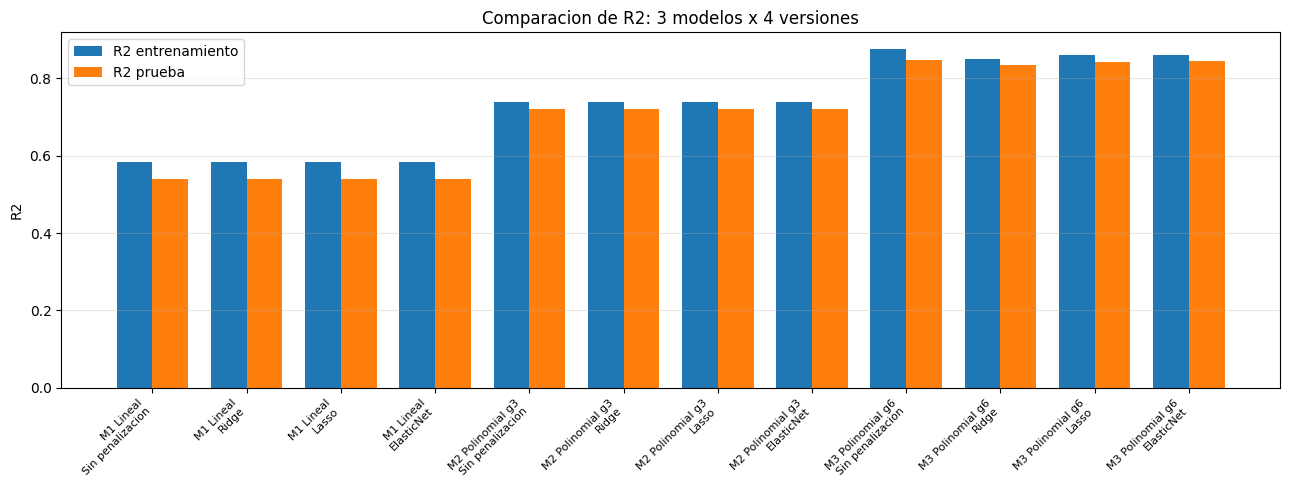

In [33]:
# Grafica de barras: R2 de entrenamiento vs prueba para los 12 ajustes
fig, ax = plt.subplots(figsize=(13, 5))

etiquetas = resultados['Modelo'] + '\n' + resultados['Version']
posicion = np.arange(len(resultados))
ancho = 0.38

ax.bar(posicion - ancho/2, resultados['R2 train'], ancho, label='R2 entrenamiento')
ax.bar(posicion + ancho/2, resultados['R2 test'], ancho, label='R2 prueba')

ax.set_xticks(posicion)
ax.set_xticklabels(etiquetas, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('R2')
ax.set_title('Comparacion de R2: 3 modelos x 4 versiones')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

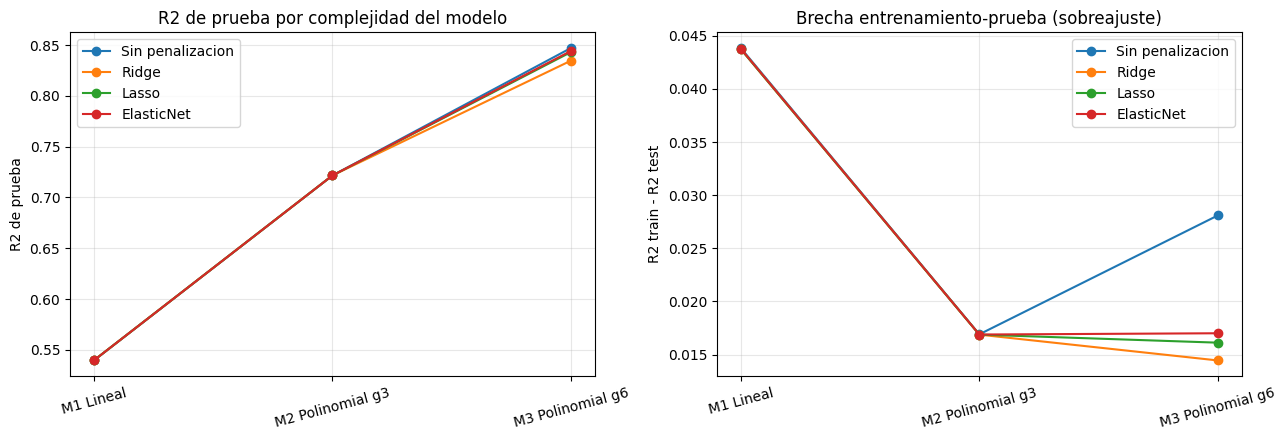

In [34]:
# Como avanza el R2 de prueba al subir la complejidad del modelo
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

modelos = ['M1 Lineal', 'M2 Polinomial g3', 'M3 Polinomial g6']
for version in ['Sin penalizacion', 'Ridge', 'Lasso', 'ElasticNet']:
    sub = resultados[resultados['Version'] == version].set_index('Modelo').loc[modelos]
    ax[0].plot(modelos, sub['R2 test'], marker='o', label=version)

ax[0].set_ylabel('R2 de prueba')
ax[0].set_title('R2 de prueba por complejidad del modelo')
ax[0].legend()
ax[0].grid(alpha=0.3)
ax[0].tick_params(axis='x', rotation=15)

# Brecha train - test: mide el sobreajuste
for version in ['Sin penalizacion', 'Ridge', 'Lasso', 'ElasticNet']:
    sub = resultados[resultados['Version'] == version].set_index('Modelo').loc[modelos]
    ax[1].plot(modelos, sub['Brecha'], marker='o', label=version)

ax[1].set_ylabel('R2 train - R2 test')
ax[1].set_title('Brecha entrenamiento-prueba (sobreajuste)')
ax[1].legend()
ax[1].grid(alpha=0.3)
ax[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Lectura de las gráficas.**

- **La complejidad sí paga.** El R² de prueba sube de forma importante de M1 a M2 y otra vez de M2 a M3, en
  las cuatro versiones. La mayor parte de la varianza que M1 no explicaba era curvatura (la sonrisa) e
  información de liquidez.
- **En M1 y M2 las cuatro versiones son prácticamente idénticas.** La validación cruzada escoge penalizaciones
  mínimas, porque con 3,500 observaciones de entrenamiento y solo 8 o 16 columnas no hay sobreajuste que
  corregir. La regularización no tiene nada que hacer ahí.
- **En M3 la regularización sí cambia las cosas.** La brecha entre entrenamiento y prueba de la versión sin
  penalización crece alrededor de 65% respecto a M2, mientras que Ridge, Lasso y ElasticNet la mantienen en
  el nivel de M2. Es la señal clásica de sobreajuste que la penalización corrige.

Como se vio en la sección 9.3, el R² de un solo conjunto de prueba puede ser engañoso para el Modelo 3 sin
penalización. Por eso **el mejor modelo se elige por R² de validación cruzada**.

In [35]:
# El mejor modelo se elige por R2 de VALIDACION CRUZADA (mas confiable que una sola particion)
mejor_fila = resultados.loc[resultados['R2 CV'].idxmax()]
print('Mejor ajuste por R2 de validacion cruzada:', mejor_fila['Modelo'], '-', mejor_fila['Version'])
print('  R2 CV   =', round(mejor_fila['R2 CV'], 4))
print('  R2 test =', round(mejor_fila['R2 test'], 4))

Mejor ajuste por R2 de validacion cruzada: M3 Polinomial g6 - Lasso
  R2 CV   = 0.8385
  R2 test = 0.8431


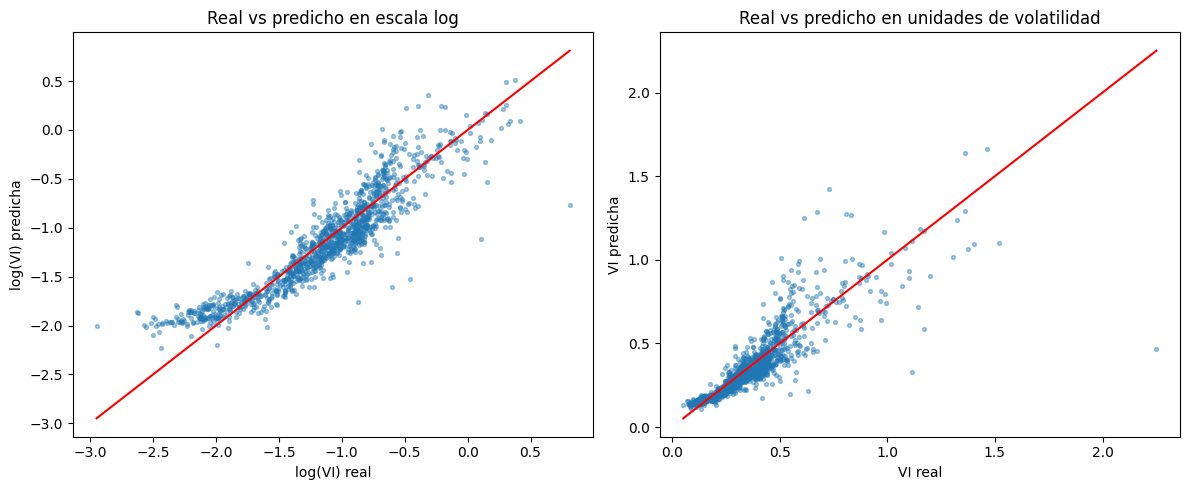

In [36]:
# Valores reales contra valores predichos del mejor modelo, en el conjunto de PRUEBA

mapa_ajustes = {'M1 Lineal': (ajustados_m1, cols_m1),
                'M2 Polinomial g3': (ajustados_m2, cols_m2),
                'M3 Polinomial g6': (ajustados_m3, cols_m3)}
ajustados_mejor, cols_mejor = mapa_ajustes[mejor_fila['Modelo']]
modelo_mejor = ajustados_mejor[mejor_fila['Version']]

pred_test = modelo_mejor.predict(X_test[cols_mejor])

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(y_test, pred_test, s=8, alpha=0.4)
lim = [y_test.min(), y_test.max()]
ax[0].plot(lim, lim, color='red')
ax[0].set_xlabel('log(VI) real'); ax[0].set_ylabel('log(VI) predicha')
ax[0].set_title('Real vs predicho en escala log')

# Mismo grafico pero deshaciendo el logaritmo, para leerlo en unidades de volatilidad
ax[1].scatter(np.exp(y_test), np.exp(pred_test), s=8, alpha=0.4)
lim2 = [np.exp(y_test).min(), np.exp(y_test).max()]
ax[1].plot(lim2, lim2, color='red')
ax[1].set_xlabel('VI real'); ax[1].set_ylabel('VI predicha')
ax[1].set_title('Real vs predicho en unidades de volatilidad')

plt.tight_layout()
plt.show()

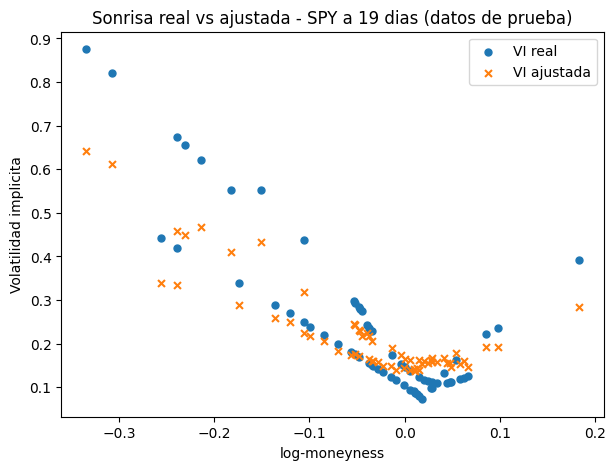

In [37]:
# Como se ve la sonrisa ajustada contra la sonrisa real
corte_test = X_test.copy()
corte_test['logIV_real'] = y_test
corte_test['logIV_pred'] = pred_test
corte_test['dias_venc'] = df.loc[X_test.index, 'dias_venc']

sel = corte_test[(corte_test['ticker'] == 'SPY') & (corte_test['dias_venc'] == venc)]

plt.figure(figsize=(7, 5))
plt.scatter(sel['logm'], np.exp(sel['logIV_real']), label='VI real', s=25)
plt.scatter(sel['logm'], np.exp(sel['logIV_pred']), label='VI ajustada', s=25, marker='x')
plt.xlabel('log-moneyness')
plt.ylabel('Volatilidad implicita')
plt.title('Sonrisa real vs ajustada - SPY a ' + str(venc) + ' dias (datos de prueba)')
plt.legend()
plt.show()

## 11. Análisis de significancia de factores (modelos sin penalización)

La significancia se analiza **solo sobre los modelos sin penalización**. Ridge, Lasso y ElasticNet
producen estimadores sesgados cuya distribución muestral no es la $t$ de Student, así que los errores
estándar y p-values que arrojarían no serían válidos.

Se usa `statsmodels.OLS` sobre exactamente la misma matriz de diseño que produce el pipeline, para que los
resultados sean directamente comparables con los de scikit-learn.

### 11.1 Modelo 1 — Lineal

In [38]:
# Transformamos con el mismo preprocesador y recuperamos los nombres de las columnas
pre_m1_fit = construir_preprocesador(['logm', 'T'], grado=1, con_interaccion=False)
X_m1_sm = pre_m1_fit.fit_transform(X_train[cols_m1])
nombres_m1 = list(pre_m1_fit.get_feature_names_out())

X_m1_sm = pd.DataFrame(X_m1_sm, columns=nombres_m1, index=X_train.index)
X_m1_sm = sm.add_constant(X_m1_sm)

ols_m1 = sm.OLS(y_train, X_m1_sm).fit()
print(ols_m1.summary())

                            OLS Regression Results                            
Dep. Variable:                  logIV   R-squared:                       0.583
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     616.8
Date:                Sun, 20 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:14:10   Log-Likelihood:                -1334.6
No. Observations:                3532   AIC:                             2687.
Df Residuals:                    3523   BIC:                             2743.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.9671      0.021  

**Lectura.** El estadístico F global es enorme y su p-value es prácticamente cero, así que el modelo en
conjunto sí explica algo. Revisando los factores uno por uno:

- **`logm`** tiene coeficiente **negativo** y es altamente significativo. Confirma la hipótesis 3: al subir
  el strike, la volatilidad implícita baja. Ese es el *skew* de renta variable, y es consistente con que el
  mercado pague una prima por protegerse de caídas.
- **`T`** también resulta significativo, lo que valida incluir el plazo.
- **Las dummies de `ticker`**: la categoría omitida es AAPL (primera en orden alfabético) y queda absorbida
  en el intercepto, así que cada coeficiente se lee como "cuánto más o menos volátil es este subyacente que
  AAPL". SPY tiene un coeficiente negativo grande (el índice es mucho menos volátil que una acción
  individual) y TSLA, NVDA y AMZN positivos. **MSFT es el único ticker no significativo al 5%**: su nivel de
  volatilidad no se distingue estadísticamente del de AAPL, lo cual tiene sentido porque son dos
  tecnológicas grandes con perfiles de riesgo parecidos.
- **La dummy de `tipo_put`** es negativa y significativa: manteniendo lo demás constante, las puts de esta
  muestra cotizan una VI menor que las calls del mismo strike. Esto es consistente con lo que se vio en la
  gráfica de la sonrisa, donde las calls dentro del dinero de la rama izquierda tenían VI mucho más alta.
  Como esa diferencia cambia con el moneyness, anticipa que la interacción `put × logm` va a importar.

El $R^2$ ajustado es cercano al $R^2$ simple, lo que era de esperarse: con pocas variables y muchas
observaciones, el castigo por número de parámetros es mínimo.

### 11.2 Modelo 2 — Polinomial grado 3 con interacción

In [39]:
pre_m2_fit = construir_preprocesador(['logm', 'T'], grado=3, con_interaccion=True)
X_m2_sm = pre_m2_fit.fit_transform(X_train[cols_m2])
nombres_m2 = list(pre_m2_fit.get_feature_names_out())

X_m2_sm = pd.DataFrame(X_m2_sm, columns=nombres_m2, index=X_train.index)
X_m2_sm = sm.add_constant(X_m2_sm)

ols_m2 = sm.OLS(y_train, X_m2_sm).fit()
print(ols_m2.summary())

                            OLS Regression Results                            
Dep. Variable:                  logIV   R-squared:                       0.739
Model:                            OLS   Adj. R-squared:                  0.737
Method:                 Least Squares   F-statistic:                     620.6
Date:                Sun, 20 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:14:10   Log-Likelihood:                -512.09
No. Observations:                3532   AIC:                             1058.
Df Residuals:                    3515   BIC:                             1163.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.27

In [40]:
# Tabla ordenada de significancia: que factores importan y cuales no
significancia = pd.DataFrame({
    'Coeficiente': ols_m2.params,
    'Error estandar': ols_m2.bse,
    'Estadistico t': ols_m2.tvalues,
    'P-value': ols_m2.pvalues,
    'IC 2.5%': ols_m2.conf_int()[0],
    'IC 97.5%': ols_m2.conf_int()[1],
})
significancia['Significativo al 5%'] = np.where(significancia['P-value'] < 0.05, 'Si', 'No')

print('Factores NO significativos al 5%:')
print(significancia[significancia['Significativo al 5%'] == 'No'].round(4).to_string())
print()
print('Total de factores:', len(significancia))
print('Significativos:   ', int((significancia['P-value'] < 0.05).sum()))

Factores NO significativos al 5%:
                  Coeficiente  Error estandar  Estadistico t  P-value  IC 2.5%  IC 97.5% Significativo al 5%
cat__ticker_MSFT        0.038          0.0206         1.8389    0.066  -0.0025    0.0784                  No

Total de factores: 17
Significativos:    16


In [41]:
significancia.sort_values('P-value').round(4)

,Coeficiente,Error estandar,Estadistico t,P-value,IC 2.5%,IC 97.5%,Significativo al 5%
const,-1.2714,0.0195,-65.3400,0.0000,-1.3096,-1.2333,Si
num__logm,-0.4555,0.0118,-38.4418,0.0000,-0.4787,-0.4322,Si
num__logm^2,0.1317,0.0045,29.5624,0.0000,0.1229,0.1404,Si
cat__ticker_SPY,-0.4147,0.0178,-23.3591,0.0000,-0.4495,-0.3799,Si
num__logm^3,0.0781,0.0036,21.9698,0.0000,0.0711,0.0851,Si
cat__tipo_put,-0.2036,0.0098,-20.6706,0.0000,-0.2229,-0.1842,Si
cat__ticker_TSLA,0.3813,0.0211,18.0778,0.0000,0.3399,0.4226,Si
num__logm^2 T,-0.0616,0.0038,-16.3719,0.0000,-0.0690,-0.0542,Si
inter__inter_put_logm,0.1078,0.0066,16.3254,0.0000,0.0948,0.1207,Si
num__T^2,0.2887,0.0186,15.5382,0.0000,0.2523,0.3252,Si


**Lectura de la significancia del Modelo 2.** El estadístico F global vuelve a ser enorme, y de los 16
factores **15 son significativos al 5%**. El único que no lo es sigue siendo la dummy de MSFT, por la misma
razón que en el Modelo 1.

- **`logm` tiene coeficiente negativo** y es el término con el estadístico t más grande: el *skew* sigue
  siendo el efecto dominante.
- **El término cuadrático `logm²` es positivo y fuertemente significativo.** Esta es la confirmación
  estadística de la hipótesis 2: la sonrisa de volatilidad existe, y es la pieza que más le faltaba al
  Modelo 1.
- **El término cúbico `logm³` también es significativo**, lo que indica que la sonrisa **no es simétrica**:
  una parábola pura no bastaría.
- **La interacción `put × logm` es significativa y positiva**, confirmando la hipótesis 4: la pendiente de
  la VI respecto al moneyness no es la misma para puts que para calls. Para las puts, la pendiente negativa
  de `logm` se compensa parcialmente, es decir, su skew es menos pronunciado.
- **El término cruzado `logm · T` es significativo y positivo.** Como el coeficiente de `logm` es negativo,
  un término cruzado positivo significa que conforme el plazo crece, la pendiente se vuelve menos negativa:
  **el skew se aplana en los vencimientos largos** y es más pronunciado en los cortos. Esta es una
  interacción entre variables cuantitativas con una interpretación financiera concreta.
- **Las potencias de `T` (`T²`, `T³`) son significativas**, lo que confirma que la estructura temporal no
  es lineal, como se vio en la gráfica exploratoria.

Comparando con el Modelo 1: el $R^2$ sube de 0.58 a 0.74 y el $R^2$ ajustado sube prácticamente lo mismo,
es decir, la mejora **no** viene de haber agregado columnas porque sí.

### 11.3 Nota sobre el Modelo 3

El Modelo 3 tiene 216 columnas en su matriz de diseño. Un `summary()` de OLS para ese modelo sería
técnicamente posible pero **no interpretable**: con tantos contrastes simultáneos, una parte de los
p-values bajos aparecería por puro azar (problema de comparaciones múltiples), y las potencias sucesivas
están tan correlacionadas entre sí que los errores estándar individuales se disparan y los signos de los
coeficientes se vuelven inestables.

Ese es exactamente el escenario para el que existe la regularización: cuando el objetivo es predecir y no
interpretar, Ridge y ElasticNet controlan la varianza de los coeficientes sin necesidad de decidir a mano
qué términos conservar. Por eso el análisis de significancia se restringe a los modelos 1 y 2, que sí son
interpretables, y el Modelo 3 se juzga por su desempeño fuera de muestra.

## 12. Diagnóstico de los seis problemas de la regresión

Se aplica sobre el **Modelo 2 sin penalización**, que es el modelo interpretable de referencia.

### 12.1 No linealidad

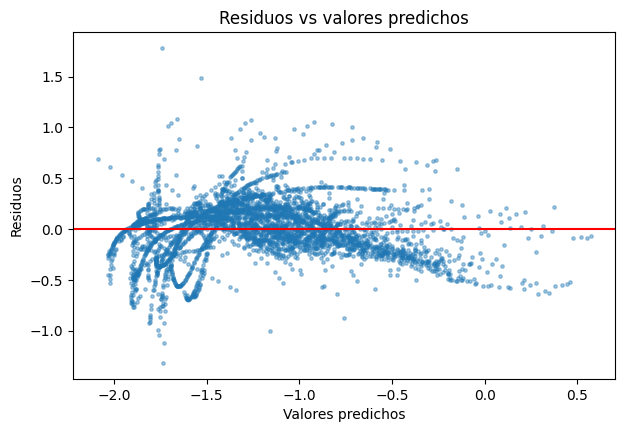

RESET -> Estadistico F: 807.9483
RESET -> P-value: 3.778339257881959e-160


In [42]:
pred_diag = ols_m2.predict(X_m2_sm)
residuos_diag = ols_m2.resid

plt.figure(figsize=(7, 4.5))
plt.scatter(pred_diag, residuos_diag, s=6, alpha=0.4)
plt.axhline(0, color='red')
plt.xlabel('Valores predichos')
plt.ylabel('Residuos')
plt.title('Residuos vs valores predichos')
plt.show()

# Prueba RESET: si el p-value es menor a 0.05 falta alguna parte no lineal
reset = linear_reset(ols_m2, power=2, use_f=True)
print('RESET -> Estadistico F:', round(reset.fvalue, 4))
print('RESET -> P-value:', reset.pvalue)

### 12.2 Correlación de errores

In [43]:
DW = durbin_watson(residuos_diag)
print('Durbin-Watson:', round(DW, 4))

Durbin-Watson: 1.9668


### 12.3 Colinealidad

In [44]:
VIF = pd.DataFrame()
VIF['Variable'] = X_m2_sm.columns
VIF['VIF'] = [variance_inflation_factor(X_m2_sm.values, i) for i in range(X_m2_sm.shape[1])]

VIF[VIF['Variable'] != 'const'].sort_values('VIF', ascending=False).round(3)

,Variable,VIF
9,num__T^3,62.893
5,num__T^2,53.852
1,num__logm,6.307
8,num__logm T^2,6.300
2,num__T,5.384
4,num__logm T,5.294
6,num__logm^3,4.751
14,cat__ticker_SPY,3.516
7,num__logm^2 T,2.393
12,cat__ticker_MSFT,2.283


### 12.4 Outliers

Numero de outliers (|residuo studentizado| > 3): 36
Porcentaje de la muestra: 1.02 %


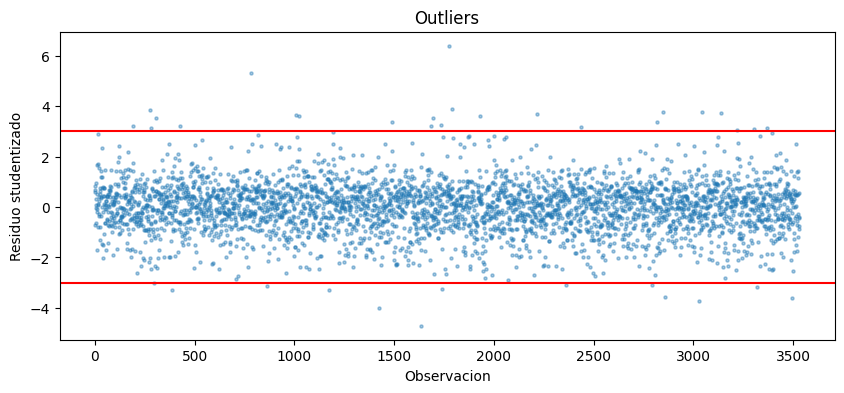

In [45]:
influencia = ols_m2.get_influence()
residuos_student = influencia.resid_studentized_external

outliers = np.where(np.abs(residuos_student) > 3)[0]
print('Numero de outliers (|residuo studentizado| > 3):', len(outliers))
print('Porcentaje de la muestra:', round(100*len(outliers)/len(residuos_student), 2), '%')

plt.figure(figsize=(10, 4))
plt.scatter(range(len(residuos_student)), residuos_student, s=5, alpha=0.4)
plt.axhline(3, color='red')
plt.axhline(-3, color='red')
plt.xlabel('Observacion')
plt.ylabel('Residuo studentizado')
plt.title('Outliers')
plt.show()

### 12.5 High leverage points

Limite 2p/n: 0.00963
Numero de High Leverage Points: 307
Porcentaje de la muestra: 8.69 %


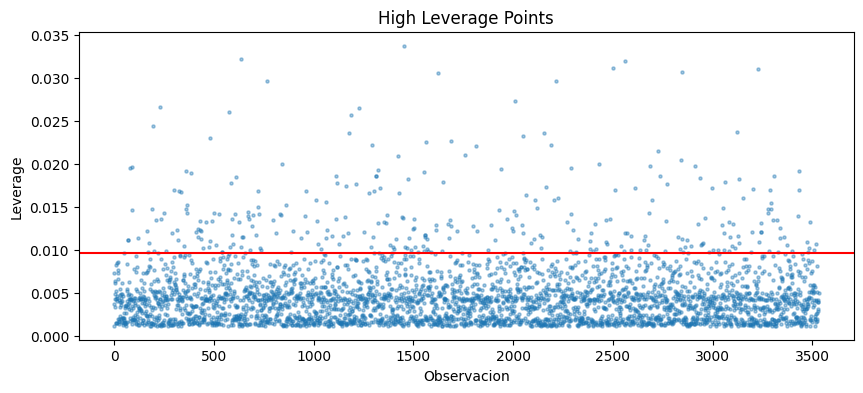

In [46]:
leverage = influencia.hat_matrix_diag

n = X_m2_sm.shape[0]
p = X_m2_sm.shape[1]
limite = 2*p/n

HL = np.where(leverage > limite)[0]
print('Limite 2p/n:', round(limite, 5))
print('Numero de High Leverage Points:', len(HL))
print('Porcentaje de la muestra:', round(100*len(HL)/n, 2), '%')

plt.figure(figsize=(10, 4))
plt.scatter(range(len(leverage)), leverage, s=5, alpha=0.4)
plt.axhline(limite, color='red')
plt.xlabel('Observacion')
plt.ylabel('Leverage')
plt.title('High Leverage Points')
plt.show()

¿Quiénes son los outliers y los high leverage points? Se comparan sus características promedio contra
las del resto de la muestra.

In [47]:
# Caracteristicas de cada grupo
info = X_train[['logm', 'T', 'logvol', 'logoi']].copy()
info['|logm|'] = np.abs(info['logm'])
info['es outlier'] = np.isin(np.arange(len(info)), outliers)
info['es high leverage'] = np.isin(np.arange(len(info)), HL)

columnas_ver = ['|logm|', 'T', 'logvol', 'logoi']
perfil = pd.DataFrame({
    'Outliers': info[info['es outlier']][columnas_ver].mean(),
    'High leverage': info[info['es high leverage']][columnas_ver].mean(),
    'Resto de la muestra': info[~info['es outlier'] & ~info['es high leverage']][columnas_ver].mean(),
})
print('Promedio de cada variable por grupo:')
print(perfil.round(3))
print()
print('Observaciones que son outlier Y high leverage a la vez:',
      int((info['es outlier'] & info['es high leverage']).sum()))

Promedio de cada variable por grupo:
        Outliers  High leverage  Resto de la muestra
|logm|     0.115          0.266                0.100
T          0.101          0.771                0.274
logvol     1.702          2.364                3.298
logoi      1.857          5.749                5.545

Observaciones que son outlier Y high leverage a la vez: 4


### 12.6 Heterocedasticidad

In [48]:
BP = het_breuschpagan(residuos_diag, ols_m2.model.exog)
print('Breusch-Pagan -> LM:', round(BP[0], 4))
print('Breusch-Pagan -> P-value:', BP[1])

# La desviacion de los residuos por quintil de volumen (fuente de la heterocedasticidad)
grupos_liq2 = pd.qcut(X_train['logvol'].rank(method='first'), 5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
print()
print('Desviacion de los residuos por quintil de volumen (Q1 = menos liquido):')
print(residuos_diag.groupby(grupos_liq2).std().round(4).to_string())

Breusch-Pagan -> LM: 698.0755
Breusch-Pagan -> P-value: 3.321005587460469e-138

Desviacion de los residuos por quintil de volumen (Q1 = menos liquido):
logvol
Q1    0.3129
Q2    0.2877
Q3    0.2588
Q4    0.2451
Q5    0.2761


Como la heterocedasticidad no desaparece, los errores estándar "normales" de MCO dejan de ser
confiables. La corrección estándar es recalcularlos con **errores estándar robustos a heterocedasticidad**
(tipo HC3). Los coeficientes no cambian; solo cambian sus errores estándar y, por lo tanto, sus p-values. Si
las conclusiones de significancia se mantienen con errores robustos, entonces no dependían del supuesto de
varianza constante.

In [49]:
# Mismo modelo, pero con errores estandar robustos (HC3)
ols_m2_robusto = sm.OLS(y_train, X_m2_sm).fit(cov_type='HC3')

robustez = pd.DataFrame({
    'Coeficiente': ols_m2.params,
    'P-value normal': ols_m2.pvalues,
    'P-value robusto (HC3)': ols_m2_robusto.pvalues,
})
robustez['Signif. normal'] = np.where(robustez['P-value normal'] < 0.05, 'Si', 'No')
robustez['Signif. robusto'] = np.where(robustez['P-value robusto (HC3)'] < 0.05, 'Si', 'No')

print(robustez.round(4).to_string())
print()
cambios = (robustez['Signif. normal'] != robustez['Signif. robusto']).sum()
print('Factores que cambian de conclusion al usar errores robustos:', int(cambios))

                       Coeficiente  P-value normal  P-value robusto (HC3) Signif. normal Signif. robusto
const                      -1.2714          0.0000                 0.0000             Si              Si
num__logm                  -0.4555          0.0000                 0.0000             Si              Si
num__T                     -0.0966          0.0000                 0.0000             Si              Si
num__logm^2                 0.1317          0.0000                 0.0000             Si              Si
num__logm T                 0.0546          0.0000                 0.0000             Si              Si
num__T^2                    0.2887          0.0000                 0.0000             Si              Si
num__logm^3                 0.0781          0.0000                 0.0000             Si              Si
num__logm^2 T              -0.0616          0.0000                 0.0000             Si              Si
num__logm T^2              -0.0176          0.0001     

In [50]:
# Resumen del diagnostico en una sola tabla
diagnostico = pd.DataFrame({
    'Problema': ['No linealidad', 'Correlacion de errores', 'Colinealidad',
                 'Outliers', 'High leverage points', 'Heterocedasticidad'],
    'Prueba / criterio': ['RESET (power=2)', 'Durbin-Watson', 'VIF maximo (sin constante)',
                          '|residuo studentizado| > 3', 'leverage > 2p/n', 'Breusch-Pagan'],
    'Valor': [round(reset.pvalue, 6),
              round(DW, 4),
              round(VIF[VIF['Variable'] != 'const']['VIF'].max(), 2),
              len(outliers),
              len(HL),
              float('%.3g' % BP[1])],
    'Referencia': ['p < 0.05 indica problema', 'ideal cerca de 2', 'VIF > 10 es problema serio',
                   'cuenta de observaciones', 'cuenta de observaciones', 'p < 0.05 indica problema']
})
diagnostico

,Problema,Prueba / criterio,Valor,Referencia
0,No linealidad,RESET (power=2),0.000000e+00,p < 0.05 indica problema
1,Correlacion de errores,Durbin-Watson,1.966800e+00,ideal cerca de 2
2,Colinealidad,VIF maximo (sin constante),6.289000e+01,VIF > 10 es problema serio
3,Outliers,|residuo studentizado| > 3,3.600000e+01,cuenta de observaciones
4,High leverage points,leverage > 2p/n,3.070000e+02,cuenta de observaciones
5,Heterocedasticidad,Breusch-Pagan,3.320000e-138,p < 0.05 indica problema


**Lectura del diagnóstico completo del Modelo 2.**

| Problema | Resultado | ¿Hay problema? |
|----------|-----------|----------------|
| No linealidad | RESET con p-value prácticamente 0 | **Sí** |
| Correlación de errores | Durbin–Watson ≈ 1.97 | No |
| Colinealidad | VIF de 54–63 en `T²` y `T³`; el resto por debajo de 7 | **Sí, localizada en las potencias del plazo** |
| Outliers | 36 observaciones (≈1% de la muestra) | Sí, pero pocos |
| High leverage points | 307 observaciones (≈8.7%) | Sí |
| Heterocedasticidad | Breusch–Pagan con p-value prácticamente 0 | **Sí** |

- **No linealidad.** La prueba RESET todavía detecta curvatura sin capturar. Es consistente con lo que se vio
  en los residuos: el polinomio de grado 3 captura la forma general de la sonrisa, pero no su fondo
  "puntiagudo" cerca del *at the money*, ni el efecto de la liquidez. Esto es justamente lo que motivó el
  Modelo 3, y el aumento de R² de M2 a M3 confirma que había estructura por explicar.
- **Correlación de errores.** El Durbin–Watson sale muy cerca de 2. Tiene sentido: los datos son un corte
  transversal del mercado, no una serie de tiempo, así que no hay razón estructural para esperar
  autocorrelación.
- **Colinealidad.** Hay un resultado interesante: las potencias de `logm` tienen VIF bajos (entre 1.4 y
  6.3), porque estandarizar antes de elevar al cuadrado y al cubo reduce mucho la correlación entre ellas.
  En cambio, `T²` y `T³` tienen VIF mayores a 50. La razón es que el plazo toma **muy pocos valores
  distintos** (8 vencimientos por subyacente) y está concentrado en los plazos cortos, así que sus potencias
  se mueven casi juntas aunque se estandaricen. La colinealidad no sesga las predicciones, pero sí vuelve
  inestables los coeficientes individuales del plazo; es otra razón para preferir un modelo regularizado
  cuando el objetivo es predecir.
- **Outliers.** Son pocos (≈1%) y tienen un perfil claro: su volumen y su interés abierto son **mucho
  menores** que los del resto de la muestra, y su plazo es corto. Es decir, son contratos poco operados cuya
  VI refleja una cotización de pantalla más que una operación real. No se eliminan porque la limpieza ya
  aplicó filtros de liquidez y de moneyness; volver a podarlos sería ajustar los datos hasta que confirmen
  el modelo.
- **High leverage points.** También tienen un perfil claro: están **lejos del dinero** (su |log-moneyness|
  promedio es más del doble que el del resto) y en **vencimientos largos**. Son las esquinas de la
  superficie, donde hay menos contratos. Son observaciones legítimas, no errores de captura. Solo 4
  observaciones son a la vez outlier y high leverage, que es la combinación realmente peligrosa.
- **Heterocedasticidad.** Sigue presente. Una fuente concreta es la liquidez: la dispersión de los residuos
  es mayor en los contratos menos operados. Como corrección se recalcularon los errores estándar con el
  estimador robusto HC3, y **las conclusiones de significancia se sostienen**: todos los factores que eran
  significativos lo siguen siendo. El único cambio es la dummy de MSFT, que pasa de no significativa
  (p ≈ 0.066) a significativa (p ≈ 0.017), lo cual indica que esa diferencia es frágil y depende del
  supuesto que se haga sobre la varianza.

## 13. Conclusión

Las conclusiones se organizan siguiendo **los objetivos planteados en la sección 1**, y se apoyan en los
resultados obtenidos a lo largo del notebook.

In [51]:
# Resumen numerico que respalda la conclusion
print('=== RESUMEN DE RESULTADOS ===')
print()
print(resultados[['Modelo', 'Version', 'alpha', 'R2 train', 'R2 test', 'R2 CV',
                  'No. coef', 'Coef != 0', 'Brecha']].round(4).to_string(index=False))
print()
print('Mejor ajuste por R2 de validacion cruzada:', mejor_fila['Modelo'], '-', mejor_fila['Version'],
      '-> R2 CV =', round(mejor_fila['R2 CV'], 4), '| R2 test =', round(mejor_fila['R2 test'], 4))
print()
mejor_por_modelo = resultados.loc[resultados.groupby('Modelo')['R2 CV'].idxmax()]
print('Mejor version dentro de cada modelo (por R2 CV):')
print(mejor_por_modelo[['Modelo', 'Version', 'R2 CV', 'R2 test']].round(4).to_string(index=False))
print('(en M1 y M2 las cuatro versiones empatan practicamente; la diferencia esta en el cuarto decimal)')
print()
print('Ganancia de M1 a M2 (sin penalizacion):',
      round(tabla_m2.loc[0, 'R2 test'] - tabla_m1.loc[0, 'R2 test'], 4))
print('Ganancia de M2 a M3 (sin penalizacion):',
      round(tabla_m3.loc[0, 'R2 test'] - tabla_m2.loc[0, 'R2 test'], 4))

=== RESUMEN DE RESULTADOS ===

          Modelo          Version    alpha  R2 train  R2 test  R2 CV  No. coef  Coef != 0  Brecha
       M1 Lineal Sin penalizacion      NaN    0.5835   0.5396 0.5811         8          8  0.0439
       M1 Lineal            Ridge   1.0000    0.5835   0.5397 0.5811         8          8  0.0438
       M1 Lineal            Lasso   0.0001    0.5835   0.5397 0.5811         8          8  0.0438
       M1 Lineal       ElasticNet   0.0001    0.5835   0.5397 0.5811         8          8  0.0438
M2 Polinomial g3 Sin penalizacion      NaN    0.7386   0.7217 0.7350        16         16  0.0169
M2 Polinomial g3            Ridge   1.0000    0.7386   0.7217 0.7350        16         16  0.0169
M2 Polinomial g3            Lasso   0.0001    0.7386   0.7217 0.7350        16         16  0.0169
M2 Polinomial g3       ElasticNet   0.0001    0.7386   0.7217 0.7350        16         16  0.0169
M3 Polinomial g6 Sin penalizacion      NaN    0.8752   0.8471 0.6823       216        2

### 13.1 Respecto al objetivo general

El objetivo general era construir y comparar modelos de regresión que explicaran la volatilidad implícita
de las opciones a partir de las características del contrato, y determinar qué nivel de complejidad y qué
tipo de penalización describen mejor la superficie de volatilidad.

**Se cumplió, y la respuesta es clara:** la superficie de volatilidad requiere un modelo no lineal de
complejidad alta, y a ese nivel de complejidad **la regularización deja de ser opcional**. El mejor ajuste
fue el **Modelo 3 con Lasso**, con un R² de validación cruzada de **0.84** y un R² de prueba de **0.84**,
usando solo 136 de sus 216 columnas. Es decir, un modelo con variables observables del contrato explica
alrededor del 84% de la variación del logaritmo de la volatilidad implícita en datos que no vio al
entrenarse.

### 13.2 Respecto a los objetivos específicos

**1. Análisis del dataset.** Se trabajó con 8,953 contratos de 6 subyacentes y 8 vencimientos cada uno.
Casi la mitad (47%) se eliminó en la limpieza por no tener precio real de mercado, tener una VI degenerada o
estar demasiado lejos del dinero. Esa proporción no es un defecto del trabajo sino una característica del
mercado de opciones: la mayor parte de los strikes listados casi no se operan.

**2. Transformaciones.** Todas las transformaciones se justificaron. El *log-moneyness* hizo comparables
contratos de subyacentes con precios muy distintos; el logaritmo de la liquidez comprimió variables con
colas muy largas; y el logaritmo de la VI se adoptó **a partir de los residuos**: redujo el sesgo de los
residuos de 3.3 a 0.9, eliminó el patrón de embudo proporcional al nivel y garantizó predicciones positivas.
No eliminó por completo la heterocedasticidad, y eso se reportó en lugar de ocultarse.

**3. Pipeline.** El pipeline integró limpieza, transformación de columnas, escalamiento, generación de
potencias y codificación de factores cualitativos, ajustando todo **solo con el conjunto de entrenamiento**.
Esto evitó *data leakage* y permitió que la comparación entre los doce ajustes fuera justa.

**4. Tres modelos en cuatro versiones.** Los resultados muestran una progresión clara:

| Modelo | R² CV (sin penalización) | R² CV (mejor versión) | R² prueba (mejor versión por CV) |
|--------|--------------------------|------------------------|----------------------------------|
| M1 Lineal | 0.58 | 0.58 | 0.54 |
| M2 Polinomial grado 3 + interacción | 0.735 | 0.735 | 0.72 |
| M3 Polinomial grado 6 + liquidez | 0.68 | **0.84 (Lasso)** | **0.84** |

**5. Residuos como guía.** Cada modelo nació de un defecto visible en los residuos del anterior: el embudo y
el sesgo del modelo con VI cruda llevaron al logaritmo; la U contra el moneyness del Modelo 1 llevó al
polinomio y a la interacción del Modelo 2; y la relación de los residuos del Modelo 2 con el volumen y el
interés abierto llevó a incluir la liquidez en el Modelo 3. En el Modelo 3 los residuos ya no muestran la
U, y su distribución es mucho más angosta y simétrica.

**6. Significancia de factores.** En el Modelo 2 sin penalización, 15 de los 16 factores son significativos
al 5%. Los resultados confirman la mayoría de las hipótesis planteadas en la sección 3.7:

- **Confirmada — la sonrisa existe:** `logm²` es positivo y muy significativo.
- **Confirmada — el skew es negativo:** `logm` tiene coeficiente negativo; al subir el strike, baja la VI.
- **Confirmada — la sonrisa es asimétrica:** `logm³` es significativo.
- **Confirmada — calls y puts tienen pendientes distintas:** la interacción `put × logm` es significativa.
- **Confirmada — el skew depende del plazo:** el término cruzado `logm · T` es significativo y positivo, lo
  que indica que el skew es más pronunciado en los vencimientos cortos y se aplana en los largos.
- **Confirmada — el subyacente importa:** SPY tiene un nivel de VI mucho menor que las acciones
  individuales, y TSLA el mayor. MSFT no se distingue de AAPL.
- **Rechazada en parte — nivel de VI en plazos cortos:** se esperaba que las opciones de corto plazo
  tuvieran VI más alta. Para esta fotografía del mercado, la VI *at the money* en general **sube** con el
  plazo (estructura en *contango*), con excepciones puntuales en vencimientos cortos. La hipótesis sobre la
  *sensibilidad* al moneyness sí se confirmó; la hipótesis sobre el *nivel* no.

Estas conclusiones se mantienen al recalcular los errores estándar con el estimador robusto HC3.

**7. Los seis problemas.** No hay correlación de errores. Sí hay no linealidad residual en el Modelo 2 (que
el Modelo 3 reduce), colinealidad localizada en las potencias del plazo, un número pequeño de outliers
asociados a contratos ilíquidos, high leverage points en las esquinas de la superficie y heterocedasticidad
asociada a la liquidez. Ninguno invalida las conclusiones principales, pero la heterocedasticidad obliga a
reportar errores robustos y la colinealidad refuerza el argumento a favor de la regularización.

**8. Comparación de los doce ajustes.** Este es el resultado central del trabajo:

- **En modelos chicos, la regularización no aporta nada.** En M1 y M2 las cuatro versiones dan
  prácticamente el mismo R². Con 3,500 observaciones de entrenamiento y 8 o 16 columnas no hay sobreajuste,
  y la validación cruzada escoge penalizaciones casi nulas.
- **En el modelo grande, la regularización es indispensable.** El Modelo 3 sin penalización tuvo el R² de
  prueba más alto de los doce ajustes (0.847), pero ese número es engañoso: en validación cruzada su R²
  promedio fue de apenas 0.68, porque en uno de los cinco pliegues cayó a 0.22. Con 216 columnas muy
  correlacionadas, MCO produce coeficientes que se cancelan entre sí y que explotan ante combinaciones de
  datos ligeramente distintas. Lasso y ElasticNet, en cambio, dieron un R² de entre 0.81 y 0.86 en **todos**
  los pliegues.
- **Lasso fue la mejor versión**, seguido muy de cerca por ElasticNet. Además de ser el más estable, Lasso
  eliminó 80 de las 216 columnas, lo que muestra que buena parte de los términos de grado alto no aportan.
  Ridge estabilizó el modelo pero quedó algo por debajo, probablemente porque conserva todos los términos y
  los encoge por igual.

### 13.3 Conclusión final

La volatilidad implícita no es constante, como supone Black–Scholes: depende de forma **no lineal** del
moneyness y del plazo, de forma distinta para calls y para puts, y con niveles propios de cada subyacente.
Un modelo lineal apenas explica el 54–58% de su variación. Al permitir curvatura e interacciones la
explicación sube al 72–74%, y al agregar la liquidez y más grados de libertad llega al 84%.

Pero ese último paso **solo es confiable con regularización**. La lección metodológica del trabajo es que
el R² de una sola partición de prueba puede premiar a un modelo inestable; la validación cruzada fue la que
reveló el problema, y la penalización fue la que lo resolvió.

### 13.4 Limitaciones y trabajo futuro

- **Es una sola fotografía del mercado.** Con datos de varios días se podría estudiar cómo cambia la
  superficie en el tiempo y validar el modelo fuera de la fecha de captura.
- **La partición es aleatoria.** El modelo interpola dentro de la superficie; no se evaluó su capacidad
  para extrapolar a vencimientos que no vio.
- **El R² se calculó en escala logarítmica.** En unidades de volatilidad el desempeño puede diferir,
  especialmente en los contratos de VI muy alta.
- **Las observaciones no son del todo independientes**, porque los contratos de un mismo vencimiento
  comparten información de mercado. Una validación cruzada agrupada por vencimiento sería más estricta.

## 14. Referencias

Breusch, T. S., & Pagan, A. R. (1979). A simple test for heteroscedasticity and random coefficient
variation. *Econometrica, 47*(5), 1287–1294. https://doi.org/10.2307/1911963

Black, F., & Scholes, M. (1973). The pricing of options and corporate liabilities. *Journal of Political
Economy, 81*(3), 637–654. https://doi.org/10.1086/260062

Derman, E., & Kani, I. (1994). Riding on a smile. *Risk, 7*(2), 32–39.

Durbin, J., & Watson, G. S. (1951). Testing for serial correlation in least squares regression II.
*Biometrika, 38*(1–2), 159–177. https://doi.org/10.1093/biomet/38.1-2.159

Gatheral, J. (2006). *The volatility surface: A practitioner's guide*. John Wiley & Sons.

Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The elements of statistical learning: Data mining,
inference, and prediction* (2nd ed.). Springer. https://doi.org/10.1007/978-0-387-84858-7

Hoerl, A. E., & Kennard, R. W. (1970). Ridge regression: Biased estimation for nonorthogonal problems.
*Technometrics, 12*(1), 55–67. https://doi.org/10.1080/00401706.1970.10488634

Hull, J. C. (2018). *Options, futures, and other derivatives* (10th ed.). Pearson.

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An introduction to statistical learning with
applications in R* (2nd ed.). Springer. https://doi.org/10.1007/978-1-0716-1418-1

Montgomery, D. C., Peck, E. A., & Vining, G. G. (2021). *Introduction to linear regression analysis*
(6th ed.). John Wiley & Sons.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M.,
Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M.,
Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning
Research, 12*, 2825–2830.

Ramsey, J. B. (1969). Tests for specification errors in classical linear least-squares regression analysis.
*Journal of the Royal Statistical Society: Series B, 31*(2), 350–371.
https://doi.org/10.1111/j.2517-6161.1969.tb00796.x

Seabold, S., & Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. En
*Proceedings of the 9th Python in Science Conference* (pp. 92–96).
https://doi.org/10.25080/Majora-92bf1922-011

Tibshirani, R. (1996). Regression shrinkage and selection via the Lasso. *Journal of the Royal Statistical
Society: Series B, 58*(1), 267–288. https://doi.org/10.1111/j.2517-6161.1996.tb02080.x

Yahoo Finance. (2026). *Option chains* [Conjunto de datos]. Recuperado mediante la librería `yfinance`.
https://finance.yahoo.com

Zou, H., & Hastie, T. (2005). Regularization and variable selection via the elastic net. *Journal of the
Royal Statistical Society: Series B, 67*(2), 301–320. https://doi.org/10.1111/j.1467-9868.2005.00503.x